In [1]:

"""
@author: SANJANA RANI
"""

#__________________________1D Mean Design_______________________________

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
import os

RESULTS = "/Users/sanju/Projects/Python/Turbine Stage Design/Report/Figures"

#Initial Values
gamma = 1.33 #Ratio of Specific Heats
k = 1.4 #Ideal gas for Compressor Only
R = 287 #J/kgK specific gas constant
T_ref = 273.0              # used for converting C -> K 

#Compressor Inlet
T_i_C = 15.0 + T_ref     # K (admission static)
P_i_C = 101325.0         # Pa (admission static)


mass_flow = 750 #kg/s
FAR = 0.025 #Fuel to Air ratio
mass_flow_compressor = mass_flow / (1.0 + FAR) 
print(f"Mass flow through compressor = {mass_flow_compressor:.3f} kg/s")

# Gas properties
Cv = R / (gamma - 1.0)
Cp = gamma * R / (gamma - 1.0)
print(f"Turbine inlet Cp = {Cp:.2f} J/kgK")
print(f"Turbine inlet Cv = {Cv:.2f} J/kgK")

# Compressor performance
pi_C = 20.0                # compressor overall pressure ratio (total-to-total) from PDF
eta_C = 0.92               # compressor isentropic efficiency (given)

# Shaft & turbine sizing limits
P_shaft_ext = 330e6        # 330 MW (turbine extracted power to shaft)
N_rot = 3000.0             # rpm (given)
U_m_limit = 350.0          # m/s peripheral velocity limit at mean radius
AN2_limit = 3.0e7          # mechanical constraint

# -----------------------------------------
# 2) Turbine inlet static conditions
# -----------------------------------------
T_1 = 1400.0 + T_ref   # K (TIT)
M_comb = 0.15   # Mach in combustor
alpha1 = 0 #degrees #Turbine inlet yaw angle (fully axial)

eff_Stator = 0.9 #Stator Efficiency
eff_Rotor = 0.9 #Rotor Efficiency
eff_stage = 0.87 #Stage Efficiency Assumed

Mass flow through compressor = 731.707 kg/s
Turbine inlet Cp = 1156.70 J/kgK
Turbine inlet Cv = 869.70 J/kgK


In [2]:
N_rot = 3000 #rpm
R_m_limit = U_m_limit/(2*np.pi*(N_rot/60)) #Mean radius
print(f'Mean-line Radius R_m (limit) = {R_m_limit:.2f} m')

Mean-line Radius R_m (limit) = 1.11 m


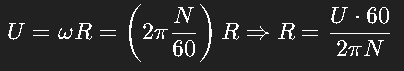

In [3]:
# -----------------------------------------
# # Compresser Calculations
# -----------------------------------------

P_e_C = P_i_C * pi_C #Compressor outlet total pressure
# Isentropic temperature rise across compressor (total temperatures)
T_es = T_i_C * (pi_C)**((k-1.0)/k)     # isentropic total temp at compressor exit
# Actual total temp at compressor exit using isentropic efficiency
T_e = T_i_C + (T_es - T_i_C) / eta_C
# Compressor power (W)
Power_C = mass_flow_compressor * (k/(k-1)) * R * T_i_C * (((P_e_C/P_i_C)**((k-1)/k))-1) * (1/(eta_C*0.95))
# Turbine must provide both compressor drive and external shaft power
Power_needed_total = P_shaft_ext + Power_C
# If this is a 4-stage turbine, per-stage available power:
Power_per_stage = Power_needed_total / 4.0

# Print compressor results
print(f"Compressor inlet T_i = {T_i_C:.2f} K, Compressor exit (total) T_e = {T_e:.2f} K")
print(f"Compressor outlet (total) P_e = {P_e_C} Pa")
print(f"Compressor total power = {Power_C/1000000:.2f} MW")
print(f"Total turbine power to provide = {Power_needed_total/1000000:.2f} MW")
print(f"Power per turbine stage = {Power_per_stage/1000000:.2f} MW")

Compressor inlet T_i = 288.00 K, Compressor exit (total) T_e = 711.72 K
Compressor outlet (total) P_e = 2026500.0 Pa
Compressor total power = 327.82 MW
Total turbine power to provide = 657.82 MW
Power per turbine stage = 164.46 MW


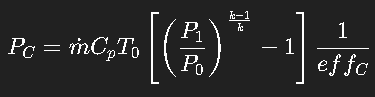

Power_ext_shaft: useful shaft power you want out (e.g. to generator or fan)
Power_C: power needed to drive the compressor

You add them: the turbine must supply both.
Then divide by 4 → assuming a 4-stage turbine, so each stage provides ¼ of total turbine power. So Power_total here = power per stage.

In [4]:
# 1] P3 Approximation

# #Issentropic Inlet calculautions
# -----------------------------------------
# 3) Turbine inlet total temperature T01
# -----------------------------------------
T_01 = T_1 * (1.0 + ((gamma - 1.0)/2.0) * M_comb**2)

# -----------------------------------------
# 4) Turbine inlet total & static pressure
# -----------------------------------------
P_1 = P_e_C = P_i_C * pi_C # total pressure at turbine inlet
P_01 = P_1 * (1.0 + ((gamma - 1.0)/2.0) * M_comb**2)**(gamma/(gamma - 1.0)) # static pressure at turbine inlet
print(f'Turbine inlet total temperature T_01  = {T_01:.2f} K')
print(f'Turbine inlet static pressure P_1 = {P_1} Pa')
print(f'Turbine inlet total pressure P_01 = {P_01} Pa')

# Turbine inlet speed of sound (static)
a_1 = np.sqrt(gamma * R * T_1)
M_1 = M_comb  # Mach number at turbine inlet

# Absolute velocity magnitude at turbine inlet
V_1 = M_1 * a_1
Vx1 = V_1 * np.cos(np.radians(alpha1))  # Axial component of V1
Vt1 = V_1 * np.sin(np.radians(alpha1))  # Tangential component of V1
print(f"Turbine inlet absolute velocity V_1 = {V_1:.2f} m/s")
print(f"Turbine inlet axial velocity Vx_1 = {Vx1:.2f} m/s")
print(f"Turbine inlet tangential velocity Vt_1 = {Vt1:.2f} m/s")



Turbine inlet total temperature T_01  = 1679.21 K
Turbine inlet static pressure P_1 = 2026500.0 Pa
Turbine inlet total pressure P_01 = 2056992.4936606083 Pa
Turbine inlet absolute velocity V_1 = 119.87 m/s
Turbine inlet axial velocity Vx_1 = 119.87 m/s
Turbine inlet tangential velocity Vt_1 = 0.00 m/s


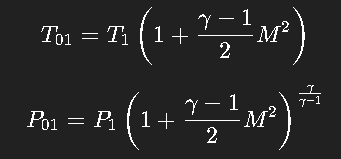

In [5]:
# -----------------------------------------
# 5) Specific work per kg for this stage
# -----------------------------------------
dH_real = Power_per_stage / mass_flow   # J/kg
print(f"Specific stage work ΔH_real  = {dH_real/1000:.2f} kJ/kg")

# ============================
# STEP 3: Isentropic exit conditions (γ = 1.33)
# ============================

# Stage efficiency (given in project brief)
eta_stage = 0.90

# -----------------------------------------
# 1) Isentropic enthalpy drop
# -----------------------------------------
dH_s = dH_real / eta_stage
print(f"Isentropic enthalpy drop ΔH_is = {dH_s/1000:.2f} kJ/kg")

psi_achieved = dH_real / U_m_limit**2
print(f"Achieved stage loading ψ = {psi_achieved}")



Specific stage work ΔH_real  = 219.27 kJ/kg
Isentropic enthalpy drop ΔH_is = 243.64 kJ/kg
Achieved stage loading ψ = 1.7899992417313013


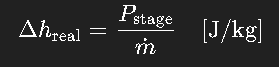

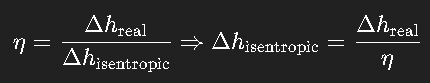

In [6]:
# -----------------------------------------
# 2) Isentropic exit total temperature
# -----------------------------------------
T_03_s = T_01 - dH_s / Cp
print(f"Isentropic exit total temperature T_03,is = {T_03_s:.2f} K")

# -----------------------------------------
# 3) Isentropic exit total pressure
# -----------------------------------------
P_03 = P_01 * (T_03_s / T_01)**(gamma/(gamma - 1.0))
print(f"Isentropic exit total pressure P_03,is = {P_03:.2f} Pa")

# -----------------------------------------
# 4) Isentropic pressure ratio across the stage
# -----------------------------------------
Pi_s = P_01 / P_03
print(f"Isentropic pressure ratio Π_is = {Pi_s:.2f}")

Isentropic exit total temperature T_03,is = 1468.58 K
Isentropic exit total pressure P_03,is = 1198493.19 Pa
Isentropic pressure ratio Π_is = 1.72


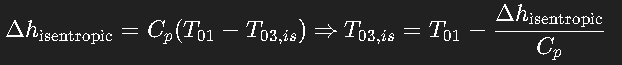
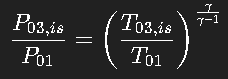

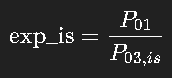

In [7]:
# 5) Choose exit Mach number (reasonable assumption)
# -----------------------------------------
M_3_s = 0.30   # typical HP turbine exit Mach
# Speed of sound at exit
a_3_s = np.sqrt(gamma * R * T_03_s)

M_3 = M_3_s
# Absolute velocity at exit
V_3_s = M_3_s * a_3_s

# Exit isentropic static temperature
T_3_s = T_03_s - V_3_s**2 / (2 * Cp)

# Exit isentropic static pressure
P_3 = P_03 * (T_3_s/T_03_s)**(gamma/(gamma - 1.0))

print(f"Isentropic exit absolute speed   a_3,is  = {a_3_s:.2f} m/s")
print(f"Isentropic exit absolute speed   V_3,is  = {V_3_s:.2f} m/s")
print(f"Isentropic exit static temperature T_3,is  = {T_3_s:.2f} K")
print(f"Isentropic exit static pressure   P_3,is  = {P_3:.2f} Pa")


Isentropic exit absolute speed   a_3,is  = 748.71 m/s
Isentropic exit absolute speed   V_3,is  = 224.61 m/s
Isentropic exit static temperature T_3,is  = 1446.77 K
Isentropic exit static pressure   P_3,is  = 1128361.14 Pa


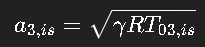
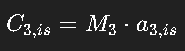

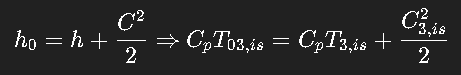

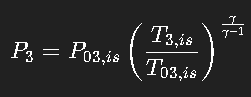

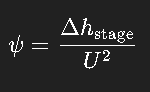

In [8]:
import numpy as np

def compute_U_from_psi(
    dH_real,   # J/kg
    psi,       # Assumed stage loading
    U_limit    # Mechanical blade speed limit (m/s)
):
    if dH_real <= 0:
        raise ValueError("dH_real must be > 0")

    if psi <= 0:
        raise ValueError("psi must be > 0")

    if U_limit <= 0:
        raise ValueError("U_limit must be > 0")

    # Blade speed from assumed psi
    U_from_psi = np.sqrt(dH_real / psi)

    # Enforce mechanical limit
    U = min(U_from_psi, U_limit)

    # Achieved stage loading from actual U
    psi_achieved = dH_real / U**2

    # ✅ Print only final results
    print(f"Final blade speed U = {U:.3f} m/s")
    print(f"Final achieved stage loading ψ = {psi_achieved:.3f}")

    return U, psi_achieved

U, psi_achieved = compute_U_from_psi(
    dH_real=dH_real,
    psi=1.8,
    U_limit=U_m_limit
)


Final blade speed U = 349.026 m/s
Final achieved stage loading ψ = 1.800


In [9]:
def compute_phi_from_U_and_Vx(
    U,    # blade speed (m/s)
    Vx    # axial velocity (m/s) - assumed constant through stage
):
    if U <= 0:
        raise ValueError("U must be > 0")
    if Vx <= 0:
        raise ValueError("Vx must be > 0")

    phi = Vx / U

    # Print only the final result
    print(f"Final flow coefficient φ = {phi:.3f}")

    return phi

phi = compute_phi_from_U_and_Vx(
    U=U,
    Vx=Vx1            # from your M_comb & alpha1
)

fi = 0.5
Vx1 = U * fi  # from inlet calculation
print(f"Axial velocity Vx1 = {Vx1:.2f} m/s")

Final flow coefficient φ = 0.343
Axial velocity Vx1 = 174.51 m/s


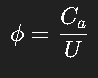

𝐶_𝑎 is usually kept nearly constant through the stage in a mean-line design

It directly affects annulus area, blade height, and Mach numbers

In [10]:
# iii) Degree of Reaction
DOR = 0.35 # Too much work to rotor will lead to lot other problems like cooling for HP turbine stage also reduce NOx


In [11]:
import numpy as np

# ---------------------------------
# Constant axial velocity across stage
# ---------------------------------
Vx2 = U * fi  # from inlet calculation


def dh_compare(P_3):
    # 2) STATOR EXIT (station 2)
    P_2 = DOR * (P_1 - P_3) + P_3

    # Isentropic expansion from (01 -> 2s)
    V_2_s = np.sqrt(2 * Cp * T_01 * (1 - (P_2 / P_1) ** ((gamma - 1.0) / gamma)))
    T_2_s = T_01 - (V_2_s**2) / (2.0 * Cp)

    V_2 = np.sqrt(eff_Stator * V_2_s**2)
    T_02 = T_01  # negligible total temperature loss in stator
    T_2 = T_02 - V_2**2 / (2.0 * Cp)

    P_02 = P_2 * (T_02 / T_2) ** (gamma / (gamma - 1.0))
    rho_2 = P_2 / (R * T_2)
    a_2 = np.sqrt(gamma * R * T_2)
    M_2 = V_2 / a_2

    # Guard acos against tiny numerical overshoot
    alpha2 = np.degrees(np.arccos(np.clip(Vx2 / V_2, -1.0, 1.0)))

    # Rotor Inlet Conditions
    Vt2 = np.sqrt(max(V_2**2 - Vx2**2, 0.0))
    Wt2 = Vt2 - U
    beta2 = np.degrees(np.arctan(Wt2 / Vx2))
    W_2 = np.sqrt(Wt2**2 + Vx2**2)
    Wx2 = np.sqrt(max(W_2**2 - Wt2**2, 0.0))
    M_w_2 = W_2 / a_2
    T_02_R = T_2 + (W_2**2) / (2 * Cp)
    P_02_R = P_2 * (T_02_R / T_2) ** (gamma / (gamma - 1.0))

    # -------------------------
    # 3) ROTOR EXIT (station 3)
    # -------------------------
    # Rotor Outlet (relative isentropic)
    W_3_s = np.sqrt(2 * Cp * T_02_R * (1 - (P_3 / P_02_R) ** ((gamma - 1.0) / gamma)))
    T_3_is_cal = T_02_R - (W_3_s**2) / (2 * Cp)

    W_3 = np.sqrt(eff_Rotor * W_3_s**2)
    T_3 = T_02_R - (W_3**2) / (2 * Cp)
    rho_3 = P_3 / (R * T_3)
    a_3 = np.sqrt(gamma * R * T_3)
    M_w_3 = W_3 / a_3

    # Total Conditions at station 3 (rotor frame)
    T_03_R = T_02_R  # assumed
    P_03_R = P_3 * (T_03_R / T_3) ** (gamma / (gamma - 1.0))

    # Rotor exit axial velocity
    VR_a = 1.0  # Axial velocity ratio = Ca3/Ca2, assumed 1
    Vx3 = Vx2 * VR_a
    Wx3 = Vx3
    beta3 = np.degrees(np.arccos(np.clip(Wx3 / W_3, -1.0, 1.0)))
    Wt3 = W_3 * np.sin(np.deg2rad(beta3))
    del_beta = beta3 + beta2

    # Absolute exit
    Vt3 = Wt3 - U
    alpha3 = np.degrees(np.arctan(Vt3 / Vx3))
    V_3 = np.sqrt(Vt3**2 + Vx3**2)
    T_03 = T_3 + V_3**2 / (2 * Cp)
    P_03 = P_3 * (T_03 / T_3) ** (gamma / (gamma - 1.0))

    dH_0 = Cp * (T_01 - T_03)

    stats = {
        "P_2": P_2,"P_02": P_02, "T_02": T_02, "T_2": T_2,  "rho_2": rho_2, "a_2": a_2, "V_2": V_2, "M_2": M_2,
        "Vx2": Vx2, "Vt2": Vt2, "alpha2": alpha2,
        "W_2": W_2, "Wx2": Wx2,"Wt2": Wt2, "beta2": beta2, "M_w_2" : M_w_2,
        "P_02_R": P_02_R, "T_02_R": T_02_R,
        "W_3": W_3, "T_3": T_3, "rho_3": rho_3,
        "Vx3": Vx3, "Vt3": Vt3, "Wx3": Wx3, "Wt3": Wt3, "a_3": a_3, "V_3": V_3, "M_w_3": M_w_3,
        "T_03_R": T_03_R, "P_03_R": P_03_R, "beta3": beta3, "alpha3": alpha3,
        "T_03": T_03, "P_03": P_03, "dH_0": dH_0
    }

    return dH_0, stats

def solve_P3(
    dH_real,
    P_1,
    P3_init=None,
    tol_dH=1e-2,
    tol_P=1e-6,
    max_iter=50,
    relax=0.4
):
    """
    Robust damped Newton solver for P3
    """

    if P3_init is None:
        P3 = 0.9 * P_1
    else:
        P3 = float(P3_init)

    P3_min = 0.1  * P_1
    P3_max = 0.999 * P_1

    for it in range(1, max_iter + 1):

        dH0, _ = dh_compare(P3)
        F = dH0 - dH_real

        # ✅ Correct primary convergence check: ENTHALPY
        if abs(F) < tol_dH:
            return P3, dH0, it

        dp = 1e-3 * max(P3, 1.0)
        P_plus  = np.clip(P3 + dp, P3_min, P3_max)
        P_minus = np.clip(P3 - dp, P3_min, P3_max)

        dH_plus,  _ = dh_compare(P_plus)
        dH_minus, _ = dh_compare(P_minus)

        F_dot = (dH_plus - dH_minus) / (P_plus - P_minus)

        if abs(F_dot) < 1e-10 or np.isnan(F_dot):
            raise RuntimeError(f"❌ Newton derivative failed at iter {it}")

        step = -F / F_dot

        # ✅ store OLD pressure before update
        P3_old = P3

        # ✅ damped update
        P3_new = P3 + relax * step
        P3 = float(np.clip(P3_new, P3_min, P3_max))

        # ✅ Correct secondary convergence: PRESSURE CHANGE
        if abs(P3 - P3_old) < tol_P * max(P3_old, 1.0):
            dH0, _ = dh_compare(P3)

            # ⚠ still enforce enthalpy check before exit
            if abs(dH0 - dH_real) < tol_dH:
                return P3, dH0, it

    raise RuntimeError("❌ P3 solver did not converge")


# =======================================
# STEP 4 — Physically constrained P3 solver
# =======================================

P_3, dH_0, iters = solve_P3(dH_real=dH_real, P_1=P_1)

print("\n===== STEP 4 RESULTS =====")
print(f"Converged P_3   = {P_3:.2f} Pa")
print(f"Iterations      = {iters}")
print(f"dH_real         = {dH_real/1000:.3f} kJ/kg")
print(f"dH0_actual      = {dH_0/1000:.3f} kJ/kg")
print(f"Residual        = {(dH_0-dH_real)/1000:.5f} kJ/kg")
print("=================================\n")

dH_0_final, stats_final = dh_compare(P_3)



===== STEP 4 RESULTS =====
Converged P_3   = 1107264.63 Pa
Iterations      = 33
dH_real         = 219.275 kJ/kg
dH0_actual      = 219.275 kJ/kg
Residual        = -0.00001 kJ/kg



In [12]:
# ============================
# ANNULUS SIZING 
# ============================

# --- Annulus sizing 
R_mean = (U * 60)/(2*(np.pi)*N_rot)
D_m2 = 2.0 * R_mean
A_2 = mass_flow / (stats_final["rho_2"] * Vx2)
height_2 = A_2 / (np.pi * D_m2)
R_t2 = R_mean + 0.5 * height_2
R_h2 = R_mean - 0.5 * height_2

Vx3 = Vx2  # axial velocity at station 3 (same as station 2)
D_m3 = D_m2 #shrouded
A_3 = mass_flow / (stats_final["rho_3"] * Vx3)
height_3 = A_3 / (np.pi * D_m3)
R_t3 = R_mean + 0.5 * height_3
R_h3 = R_mean - 0.5 * height_3

#Station 1 Calculations
A_12 = 1 #Area ratio assumed 1
A_1 = A_2
rho_1 = P_01/(R * T_01)
Vx1 = mass_flow/(rho_1 * A_1)
V_1 = Vx1/(np.cos(np.deg2rad(alpha1)))

#AN2 computing
w=U/R_mean
N=(w*60)/(2*(np.pi))
AN2=((A_3+A_2)/2)*(N**2)
#U_hub
U_hub=(U*R_h2)/R_mean

In [13]:
def design_sanity_check(stats_final):

    results = {
        "M2": {
            "value": stats_final["M_2"],
            "min": 0.70,
            "max": 0.85,
            "unit": "-"
        },
        "beta2": {
            "value": stats_final["beta2"],
            "min": None,
            "max": 47.5,
            "unit": "deg"
        },
        "Mw2": {
            "value": stats_final["W_2"] / np.sqrt(gamma * R * stats_final["T_2"]),
            "min": None,
            "max": 0.50,
            "unit": "-"
        },
        "Mw3": {
            "value": stats_final["W_3"] / np.sqrt(gamma * R * stats_final["T_3"]),
            "min": 0.65,
            "max": 0.80,
            "unit": "-"
        },
        "beta3": {
            "value": stats_final["beta3"],
            "min": None,
            "max": 75.0,
            "unit": "deg"
        },
        "Delta_beta": {
            "value": stats_final["beta2"] + stats_final["beta3"],
            "min": 110.0,
            "max": 120.0,
            "unit": "deg"
        },
        "M3": {
            "value": M_3_s,
            "min": 0.30,
            "max": 0.30,
            "unit": "-"
        },
        "alpha3": {
            "value": stats_final["alpha3"],
            "min": None,
            "max": 35.0,   # loss-allowed limit
            "unit": "deg"
        },
        "h3/h2": {
            "value": (height_3/height_2),
            "min": None,
            "max": 1.2,   # loss-allowed limit
            "unit": "-"
        },
        "AN2": {
            "value": AN2,
            "min": None,
            "max": 3e7,   # loss-allowed limit
            "unit": "$m^2 rpm^2$"
        }
    }

    print("\n========== DESIGN SANITY CHECK ==========\n")

    all_pass = True

    for key, info in results.items():
        v = info["value"]
        vmin = info["min"]
        vmax = info["max"]
        unit = info["unit"]

        if vmin is not None and v < vmin:
            status = "❌ FAIL (LOW)"
            all_pass = False
        elif vmax is not None and v > vmax:
            status = "❌ FAIL (HIGH)"
            all_pass = False
        else:
            status = "✅ PASS"

        if vmin is not None and vmax is not None:
            lim_str = f"{vmin} – {vmax}"
        elif vmin is not None:
            lim_str = f"> {vmin}"
        elif vmax is not None:
            lim_str = f"< {vmax}"
        else:
            lim_str = "—"

        print(f"{key:10s} | Limit: {lim_str:12s} | Value: {v:8.4f} {unit:3s} | {status}")

    if all_pass:
        print("\n✅ ALL DESIGN PARAMETERS WITHIN SAFE LIMITS ✅")
    else:
        print("\n⚠️ SOME DESIGN PARAMETERS VIOLATE LIMITS ⚠️")
        print("→ Consider adjusting ψ, φ or DOR.")

    print("========================================\n")

design_sanity_check(stats_final)



========== DESIGN SANITY CHECK ==========

M2         | Limit: 0.7 – 0.85   | Value:   0.6996 -   | ❌ FAIL (LOW)
beta2      | Limit: < 47.5       | Value:  42.6413 deg | ✅ PASS
Mw2        | Limit: < 0.5        | Value:   0.3081 -   | ✅ PASS
Mw3        | Limit: 0.65 – 0.8   | Value:   0.6661 -   | ✅ PASS
beta3      | Limit: < 75.0       | Value:  69.5316 deg | ✅ PASS
Delta_beta | Limit: 110.0 – 120.0 | Value: 112.1729 deg | ✅ PASS
M3         | Limit: 0.3 – 0.3    | Value:   0.3000 -   | ✅ PASS
alpha3     | Limit: < 35.0       | Value:  34.1813 deg | ✅ PASS
h3/h2      | Limit: < 1.2        | Value:   1.2214 -   | ❌ FAIL (HIGH)
AN2        | Limit: < 30000000.0 | Value: 13405704.3816 $m^2 rpm^2$ | ✅ PASS

⚠️ SOME DESIGN PARAMETERS VIOLATE LIMITS ⚠️
→ Consider adjusting ψ, φ or DOR.



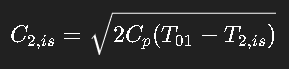

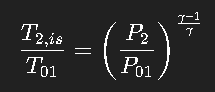

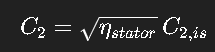

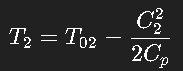

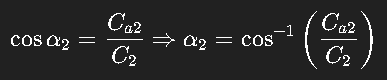

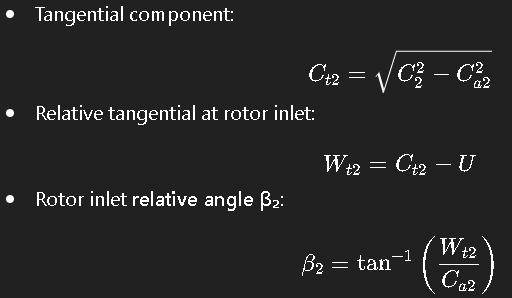

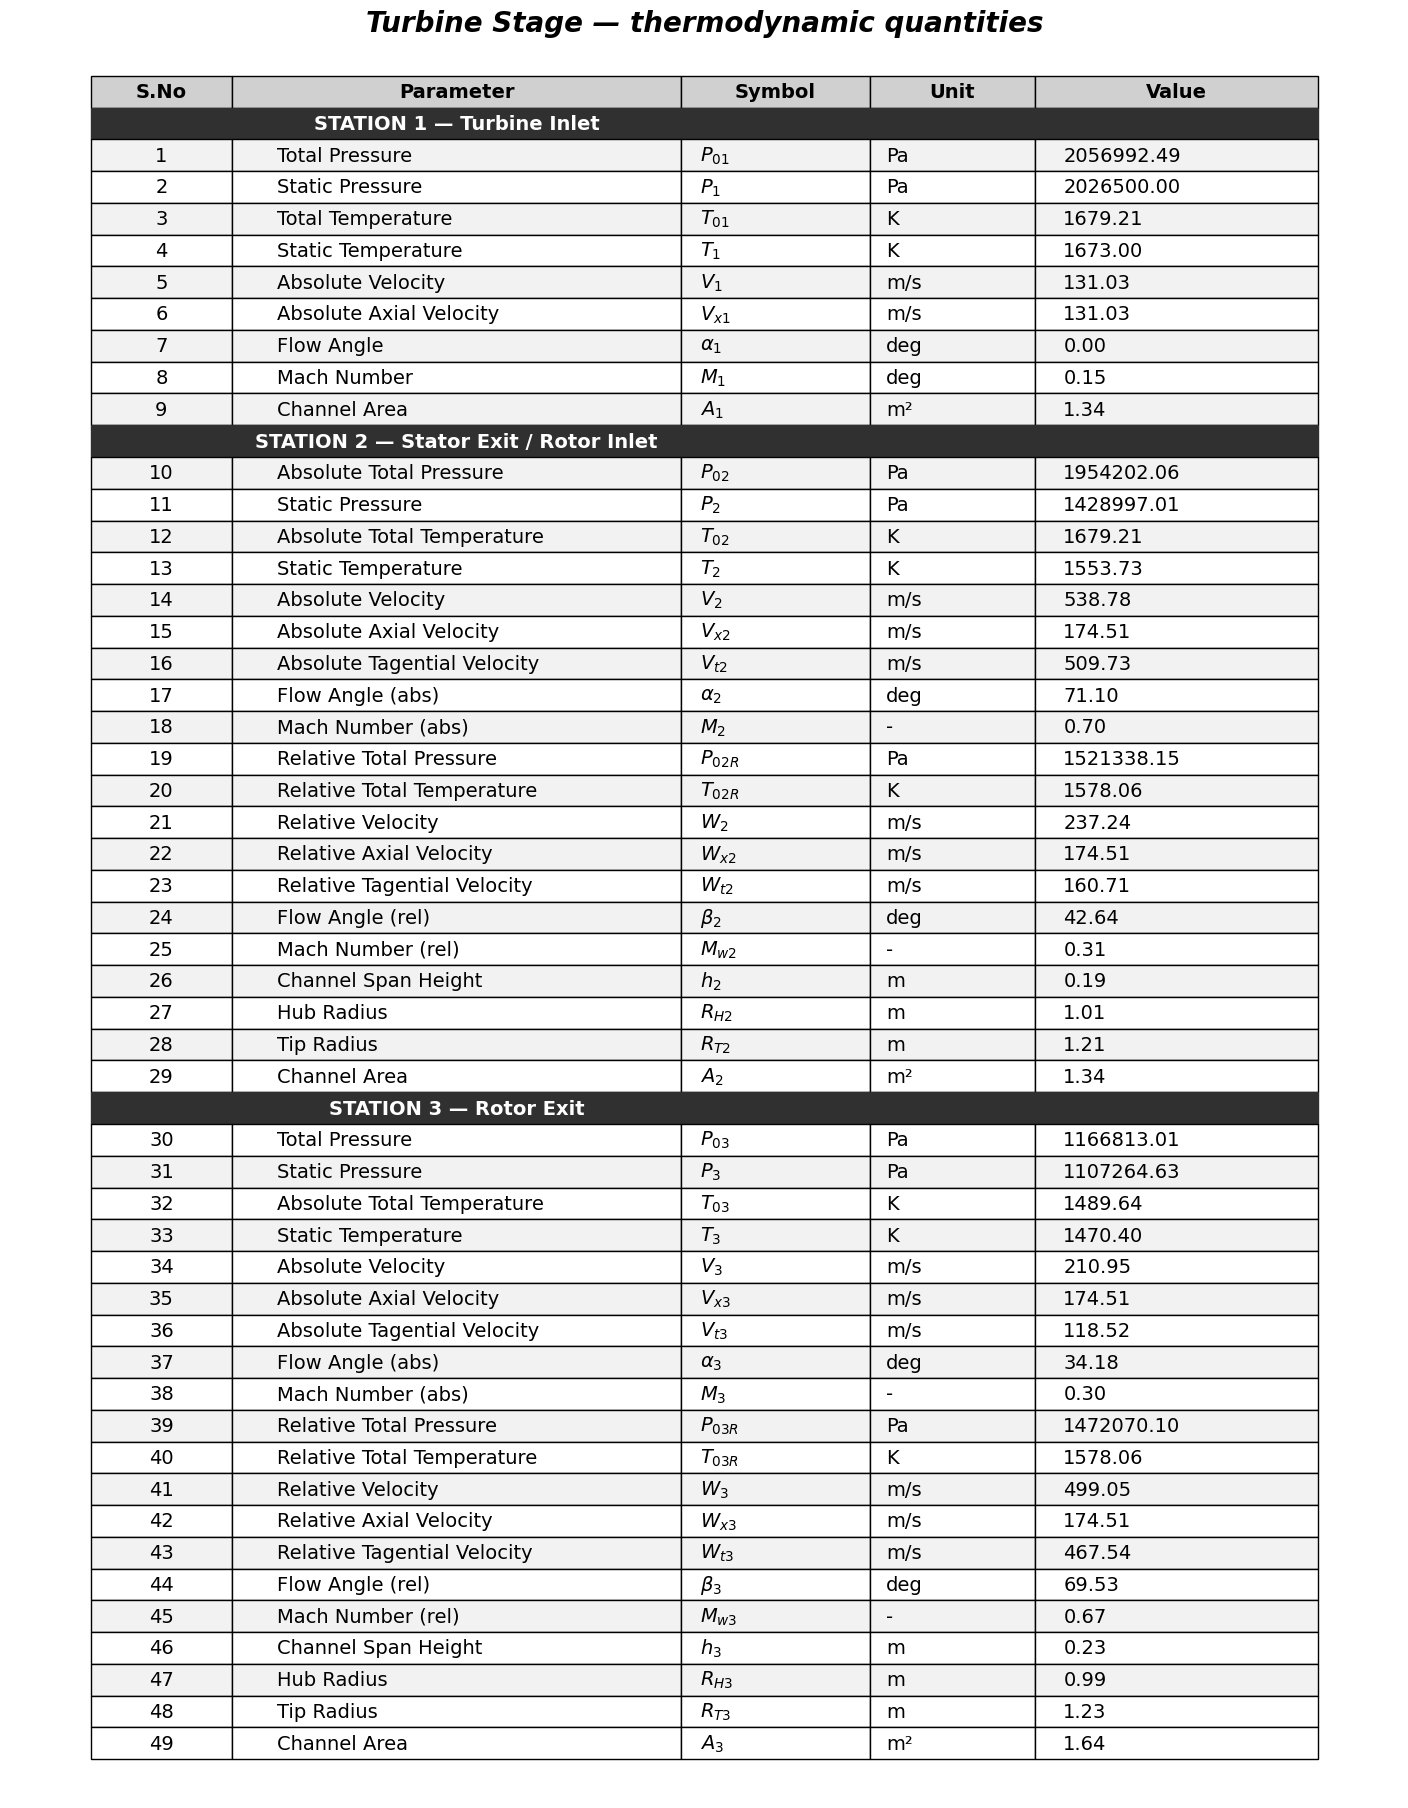

In [14]:
# ======================================================
# BUILD TABLE DATA STRUCTURE
# ======================================================

rows = []
header_rows = []   # store row indices of section headers
sno = 1            # continuous numbering


def add_header(text):
    """Insert a section header row."""
    rows.append(["", text, "", "", ""])
    header_rows.append(len(rows))   # store row index


def add_row(parameter, symbol, unit, value):
    """Insert a normal data row."""
    global sno
    rows.append([sno, parameter, symbol, unit, value])
    sno += 1


# ======================================================
# STATION 1 — TURBINE INLET
# ======================================================

add_header("STATION 1 — Turbine Inlet")

add_row("Total Pressure",          r"$P_{01}$", "Pa",  f"{P_01:.2f}")
add_row("Static Pressure",         r"$P_{1}$",  "Pa",  f"{P_1:.2f}")
add_row("Total Temperature",       r"$T_{01}$", "K",   f"{T_01:.2f}")
add_row("Static Temperature",      r"$T_{1}$",  "K",   f"{T_1:.2f}")
add_row("Absolute Velocity",       r"$V_{1}$",  "m/s", f"{V_1:.2f}")
add_row("Absolute Axial Velocity",       r"$V_{x1}$",  "m/s", f"{Vx1:.2f}")
add_row("Flow Angle",              r"$\alpha_1$", "deg", f"{alpha1:.2f}")
add_row("Mach Number",              r"$M_1$", "deg", f"{M_1:.2f}")
add_row("Channel Area",                  r"$A_1$",     "m²",     f"{A_1:.2f}")


# ======================================================
# STATION 2 — STATOR EXIT / ROTOR INLET
# ======================================================

add_header("STATION 2 — Stator Exit / Rotor Inlet")

add_row("Absolute Total Pressure",     r"$P_{02}$", "Pa",    f"{stats_final['P_02']:.2f}")
add_row("Static Pressure",             r"$P_{2}$",   "Pa",    f"{stats_final['P_2']:.2f}")
add_row("Absolute Total Temperature",     r"$T_{02}$", "K",    f"{stats_final['T_02']:.2f}")
add_row("Static Temperature",          r"$T_{2}$",   "K",     f"{stats_final['T_2']:.2f}")
add_row("Absolute Velocity",           r"$V_{2}$",     "m/s",   f"{stats_final['V_2']:.2f}")
add_row("Absolute Axial Velocity",           r"$V_{x2}$",     "m/s",   f"{stats_final['Vx2']:.2f}")
add_row("Absolute Tagential Velocity",           r"$V_{t2}$",     "m/s",   f"{stats_final['Vt2']:.2f}")
add_row("Flow Angle (abs)",            r"$\alpha_2$", "deg",  f"{stats_final['alpha2']:.2f}")
add_row("Mach Number (abs)",                  r"$M_2$",     "-",     f"{stats_final['M_2']:.2f}")
add_row("Relative Total Pressure",  r"$P_{02R}$", "Pa",     f"{stats_final['P_02_R']:.2f}")
add_row("Relative Total Temperature",  r"$T_{02R}$", "K",     f"{stats_final['T_02_R']:.2f}")
add_row("Relative Velocity",           r"$W_2$",     "m/s",   f"{stats_final['W_2']:.2f}")
add_row("Relative Axial Velocity",           r"$W_{x2}$",     "m/s",   f"{stats_final['Wx2']:.2f}")
add_row("Relative Tagential Velocity",           r"$W_{t2}$",     "m/s",   f"{stats_final['Wt2']:.2f}")
add_row("Flow Angle (rel)",            r"$\beta_2$",  "deg",  f"{stats_final['beta2']:.2f}")
add_row("Mach Number (rel)",                  r"$M_{w2}$",     "-",     f"{stats_final['M_w_2']:.2f}")
add_row("Channel Span Height",                  r"$h_2$",     "m",     f"{height_2:.2f}")
add_row("Hub Radius",                  r"$R_{H2}$",     "m",     f"{R_h2:.2f}")
add_row("Tip Radius",                  r"$R_{T2}$",     "m",     f"{R_t2:.2f}")
add_row("Channel Area",                  r"$A_2$",     "m²",     f"{A_2:.2f}")


# ======================================================
# STATION 3 — ROTOR EXIT
# ======================================================

add_header("STATION 3 — Rotor Exit")

add_row("Total Pressure",     r"$P_{03}$", "Pa",    f"{stats_final['P_03']:.2f}")
add_row("Static Pressure",             r"$P_{3}$",   "Pa",    f"{P_3:.2f}")
add_row("Absolute Total Temperature",     r"$T_{03}$", "K",    f"{stats_final['T_03']:.2f}")
add_row("Static Temperature",          r"$T_{3}$",   "K",     f"{stats_final['T_3']:.2f}")
add_row("Absolute Velocity",           r"$V_{3}$",     "m/s",   f"{stats_final['V_3']:.2f}")
add_row("Absolute Axial Velocity",           r"$V_{x3}$",     "m/s",   f"{stats_final['Vx3']:.2f}")
add_row("Absolute Tagential Velocity",           r"$V_{t3}$",     "m/s",   f"{stats_final['Vt3']:.2f}")
add_row("Flow Angle (abs)",            r"$\alpha_3$", "deg",  f"{stats_final['alpha3']:.2f}")
add_row("Mach Number (abs)",                  r"$M_3$",     "-",     f"{M_3:.2f}")
add_row("Relative Total Pressure",  r"$P_{03R}$", "Pa",     f"{stats_final['P_03_R']:.2f}")
add_row("Relative Total Temperature",  r"$T_{03R}$", "K",     f"{stats_final['T_03_R']:.2f}")
add_row("Relative Velocity",           r"$W_3$",     "m/s",   f"{stats_final['W_3']:.2f}")
add_row("Relative Axial Velocity",           r"$W_{x3}$",     "m/s",   f"{stats_final['Wx3']:.2f}")
add_row("Relative Tagential Velocity",           r"$W_{t3}$",     "m/s",   f"{stats_final['Wt3']:.2f}")
add_row("Flow Angle (rel)",            r"$\beta_3$",  "deg",  f"{stats_final['beta3']:.2f}")
add_row("Mach Number (rel)",                  r"$M_{w3}$",     "-",     f"{stats_final['M_w_3']:.2f}")
add_row("Channel Span Height",                  r"$h_3$",     "m",     f"{height_3:.2f}")
add_row("Hub Radius",                  r"$R_{H3}$",     "m",     f"{R_h3:.2f}")
add_row("Tip Radius",                  r"$R_{T3}$",     "m",     f"{R_t3:.2f}")
add_row("Channel Area",                  r"$A_3$",     "m²",     f"{A_3:.2f}")

# ======================================================
# MATPLOTLIB TABLE DISPLAY
# ======================================================

fig, ax = plt.subplots(figsize=(14, 18))
ax.axis("off")

columns = ["S.No", "Parameter", "Symbol", "Unit", "Value"]

table = ax.table(
    cellText=rows,
    colLabels=columns,
    loc="center",
    cellLoc="left",
    colWidths=[0.06, 0.19, 0.08, 0.07, 0.12]
)

table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1.70, 1.5)


# ============================================================
# STYLE HEADER ROW (column names)
# ============================================================
for c in range(5):
    table[(0, c)].set_facecolor("#d0d0d0")
    table[(0, c)].set_text_props(weight="bold", ha="center", va="center")


# ============================================================
# CENTER S.No column — FIRST PASS
# ============================================================
for r in range(1, len(rows)):
    table[(r, 0)].get_text().set_ha("center")


# ============================================================
# STYLE SECTION HEADERS (dark centered rows)
# ============================================================
fig.canvas.draw()

for r in header_rows:
    for c in range(5):
        cell = table[(r, c)]
        cell.set_facecolor("#303030")
        cell.set_edgecolor("#303030")
        cell.set_linewidth(1)
        cell.set_text_props(color="white", weight="bold", ha="center", va="center")

        if c != 1:
            cell.get_text().set_text("")   # only show text in Parameter column


# ============================================================
# ALTERNATING SHADING FOR NORMAL ROWS
# ============================================================
for r in range(1, len(rows)):
    if r not in header_rows:
        if r % 2 == 0:
            for c in range(5):
                table[(r, c)].set_facecolor("#f2f2f2")


# ============================================================
# FINAL FIX: RE-CENTER S.No COLUMN AFTER DRAW  (important!)
# ============================================================

fig.canvas.draw()  # ensure table fully rendered

for r in range(1, len(rows)):
    if r not in header_rows:
        table[(r, 0)].get_text().set_ha("center")

# explicitly fix last row (Matplotlib likes to override it…)
table[(len(rows), 0)].get_text().set_ha("center")


# ============================================================
# TITLE
# ============================================================
plt.title(
    "Turbine Stage — thermodynamic quantities",
    fontsize=20,
    fontweight='bold',
    style='italic',
    pad=4
)

plt.tight_layout(pad=0.4)

# Save figure

save_path = os.path.join(RESULTS, "Turbine Stage — thermodynamic quantities.png")

plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()



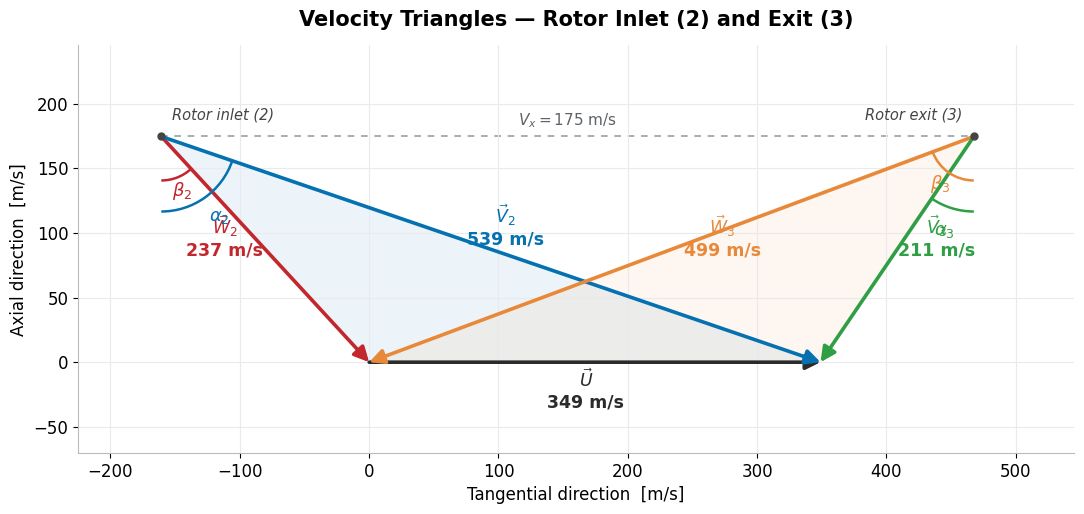

In [15]:
# ============================================================
# Velocity Triangles at Rotor Inlet (2) and Exit (3)
# ============================================================
import numpy as np, os
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Polygon, FancyArrowPatch

W2, b2 = stats_final['W_2'], stats_final['beta2']
W3, b3 = stats_final['W_3'], stats_final['beta3']
V2, a2 = stats_final['V_2'], stats_final['alpha2']
V3, a3 = stats_final['V_3'], stats_final['alpha3']
Vx     = stats_final['Vx2']

A = np.array([0.0, 0.0]); C = np.array([U, 0.0])
B = np.array([-W2*np.sin(np.radians(b2)),  W2*np.cos(np.radians(b2))])   # inlet apex
D = np.array([ W3*np.sin(np.radians(b3)),  W3*np.cos(np.radians(b3))])   # exit  apex

cU='#2b2b2b'; cV2='#0571b0'; cW2='#c1272d'; cV3='#2f9e44'; cW3='#e8893a'
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(figsize=(11, 7.4)); ax.set_facecolor('white')
ax.add_patch(Polygon([A, B, C], closed=True, facecolor=cV2, alpha=0.07, edgecolor='none'))
ax.add_patch(Polygon([A, D, C], closed=True, facecolor=cW3, alpha=0.07, edgecolor='none'))
ax.plot([B[0], D[0]], [Vx, Vx], ls=(0, (4, 4)), color='#9aa0a6', lw=1.2, zorder=1)
ax.annotate(f'$V_x = {Vx:.0f}$ m/s', xy=((B[0]+D[0])/2, Vx), xytext=(0, 8),
            textcoords='offset points', ha='center', color='#5f6368', fontsize=11)

def vec(p0, p1, color, label, mag, loff=(0, 0)):
    ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle='-|>', mutation_scale=22,
                                 lw=2.6, color=color, shrinkA=0, shrinkB=0, zorder=4))
    m = 0.52*np.array(p0) + 0.48*np.array(p1)
    ax.annotate(f'{label}\n{mag:.0f} m/s', xy=m, xytext=loff, textcoords='offset points',
                color=color, fontsize=12.5, ha='center', va='center', fontweight='bold')

vec(A, C, cU,  r'$\vec{U}$',   U,  (0, -20))
vec(B, A, cW2, r'$\vec{W}_2$', W2, (-26, 6))
vec(B, C, cV2, r'$\vec{V}_2$', V2, (20, 14))
vec(D, A, cW3, r'$\vec{W}_3$', W3, (28, 6))
vec(D, C, cV3, r'$\vec{V}_3$', V3, (26, 6))

def arc_to(apex, target, color, label, R, lr=1.32):
    d = np.array(target) - np.array(apex)
    th = np.degrees(np.arctan2(d[1], d[0])) % 360
    t1, t2 = min(th, 270.0), max(th, 270.0)
    ax.add_patch(Arc(apex, 2*R, 2*R, theta1=t1, theta2=t2, color=color, lw=1.8, zorder=5))
    mid = np.radians((t1 + t2)/2)
    ax.annotate(label, xy=(apex[0]+lr*R*np.cos(mid), apex[1]+lr*R*np.sin(mid)),
                color=color, fontsize=13, ha='center', va='center', fontweight='bold')

arc_to(B, C, cV2, r'$\alpha_2$', 58); arc_to(B, A, cW2, r'$\beta_2$', 34)
arc_to(D, C, cV3, r'$\alpha_3$', 58); arc_to(D, A, cW3, r'$\beta_3$', 34)
ax.plot(*B, 'o', color='#444', ms=5, zorder=6); ax.plot(*D, 'o', color='#444', ms=5, zorder=6)
ax.annotate('Rotor inlet (2)', xy=B, xytext=(8, 12), textcoords='offset points', ha='left', fontsize=10.5, color='#444', style='italic')
ax.annotate('Rotor exit (3)', xy=D, xytext=(-8, 12), textcoords='offset points', ha='right', fontsize=10.5, color='#444', style='italic')
ax.set_xlim(-225, 545); ax.set_ylim(-70, 245); ax.set_aspect('equal')
ax.set_xlabel('Tangential direction  [m/s]'); ax.set_ylabel('Axial direction  [m/s]')
ax.set_title('Velocity Triangles — Rotor Inlet (2) and Exit (3)', fontsize=15, fontweight='bold', pad=14)
ax.grid(True, color='#e8eaed', lw=0.8)
for s in ['top', 'right']: ax.spines[s].set_visible(False)
ax.spines['left'].set_color('#bbb'); ax.spines['bottom'].set_color('#bbb')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "Velocity Triangles at Rotor Inlet (2) and Exit (3).png"), dpi=200, bbox_inches='tight')
plt.show()


In [16]:
# ============================================================
# FULL h–s "LADDER" VALUES FOR TURBINE STAGE
# ============================================================

P1, P01 = P_1, P_01
T1, T01 = T_1, T_01

P2   = stats_final["P_2"]
T2   = stats_final["T_2"]
T02R = stats_final["T_02_R"]
P02  = stats_final["P_02"]

P03 = stats_final["P_03"]
P3  = P_3
T3   = stats_final["T_3"]
T03  = stats_final["T_03"]

V1   = V_1
V2   = stats_final["V_2"]
V3   = stats_final["V_3"]

W2   = stats_final["W_2"]
W3   = stats_final["W_3"]

# ============================================================
# 1) ENTHALPY LEVELS
# ============================================================

# ---- Station 1 ----
h1  = Cp * T1          # static
H01 = Cp * T01         # total (absolute)  ≡ H1 in many diagrams

# ---- Station 2 (real) ----
h2   = Cp * T2
H02  = H01             # ideal stator: total enthalpy conserved
H02_R = Cp * T02R      # relative total at rotor inlet

# ---- Station 2s (isentropic stator exit) ----
# same formula as inside dh_compare: T_2_s = T_01 * (P_2/P_1)^((γ-1)/γ)
T2s  = T01 * (P2/P1)**((gamma - 1.0)/gamma)
h2s  = Cp * T2s

# ---- Rotor isentropic exit (relative) ----
# Rebuild P02_R like inside dh_compare:
P02_R = P2 * (T02R / T2)**(gamma / (gamma - 1.0))

pr_ratio = P3 / P02_R
T3s_rel  = T02R * pr_ratio**((gamma - 1.0)/gamma)           # relative static T_3s
W3s      = np.sqrt(2.0 * Cp * (T02R - T3s_rel))             # isentropic relative speed

# Convert to static isentropic exit (absolute frame)
T3s  = T02R - W3s**2 / (2.0 * Cp)
h3s  = Cp * T3s

# ---- Station 3 (real) ----
h3   = Cp * T3
H03  = Cp * T03

# ---- Fully isentropic stage exit (01 → 3ss) ----
T3ss = T01 * (P3 / P01)**((gamma - 1.0)/gamma)
h3ss = Cp * T3ss
# if you want total at 3ss:
H03ss = h3ss + V3**2 / 2.0   # or just Cp*T3ss if you view it as stagnation

print("\n=========== ENTHALPY LADDER (J/kg) ===========")
print(f"h1    = {h1:.2f}")
print(f"H01   = {H01:.2f}")
print()
print(f"h2    = {h2:.2f}")
print(f"h2s   = {h2s:.2f}")
print(f"H02   = {H02:.2f}")
print(f"H02_R = {H02_R:.2f}")
print()
print(f"h3    = {h3:.2f}")
print(f"h3s   = {h3s:.2f}")
print(f"h3ss  = {h3ss:.2f}")
print(f"H03   = {H03:.2f}")
print(f'H03ss = {H03ss:.2f}')
print("===============================================\n")

# ============================================================
# 2) ENTROPY LEVELS (STATIC + TOTAL + ISENTROPIC)
# ============================================================

# Reference state (you already used this earlier — keep consistent)
T_ref_s = T1
P_ref_s = P1

def entropy(T, P):
    return Cp * np.log(T / T_ref_s) - R * np.log(P / P_ref_s)

# ---- Static entropies ----
s1   = entropy(T1,  P1)
s2   = entropy(T2,  P2)
s2s  = entropy(T2s, P2)
s3   = entropy(T3,  P3)
s3s  = entropy(T3s, P3)
s3ss = entropy(T3ss, P3)

# ---- Total entropies ----
s01  = entropy(T01, P01)
s02  = entropy(T01, P02)   # T02 = T01 (no stator total-T loss)
s03  = entropy(T03, P03)

# print("=========== ENTROPY LADDER (J/kg·K) ==========")
# print(f"s1    = {s1:.4f}")
# print(f"s01   = {s01:.4f}")
# print()
# print(f"s2    = {s2:.4f}")
# print(f"s2s   = {s2s:.4f}")
# print(f"s02   = {s02:.4f}")
# print()
# print(f"s3    = {s3:.4f}")
# print(f"s3s   = {s3s:.4f}")
# print(f"s3ss  = {s3ss:.4f}")
# print(f"s03   = {s03:.4f}")
# print("===============================================\n")




=========== ENTHALPY LADDER (J/kg) ===========
h1    = 1935154.03
H01   = 1942338.29

h2    = 1797197.71
h2s   = 1781070.98
H02   = 1942338.29
H02_R = 1825338.23

h3    = 1700812.97
h3s   = 1686976.83
h3ss  = 1665655.39
H03   = 1723063.39
H03ss = 1687905.82



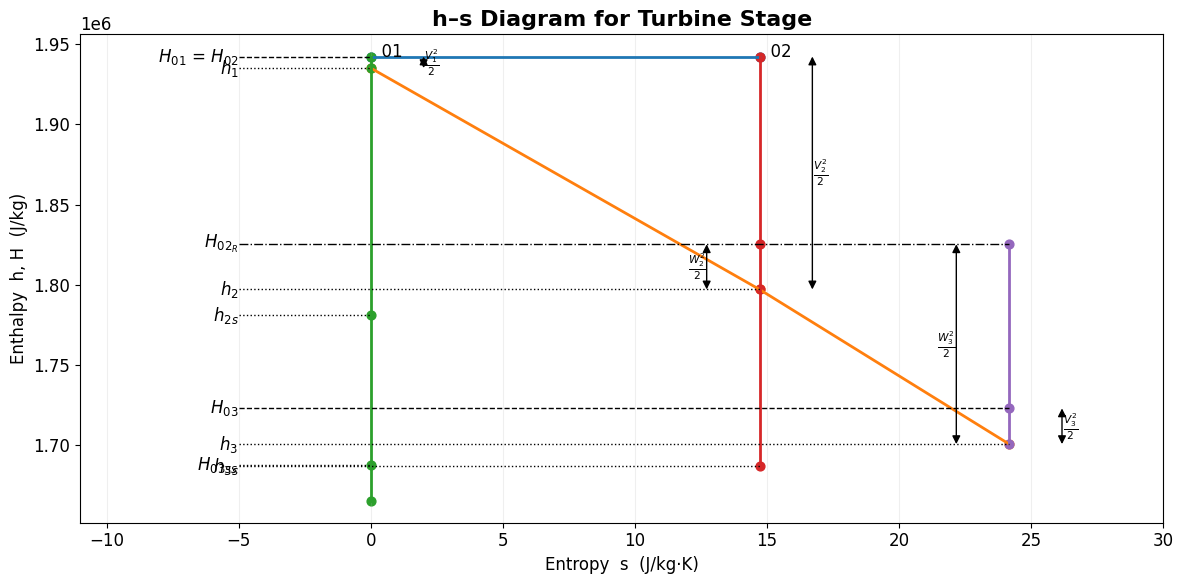

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# ---- AXES, TITLE, GRID ----
plt.xlabel("Entropy  s  (J/kg·K)")
plt.ylabel("Enthalpy  h, H  (J/kg)")
plt.title("h–s Diagram for Turbine Stage", fontsize=16, fontweight="bold")

plt.plot([s1, s2], [H01, H02], linewidth=2)
plt.scatter([s1, s2], [H01, H02], s=40)
plt.text(s1, H01, "  01")
plt.text(s2, H02, "  02")


plt.plot([s1, s2, s3], [h1, h2, h3], linewidth=2)
plt.scatter([s1, s2, s3], [h1, h2, h3], s=40)

plt.plot(
    [s1, s1, s1, s1, s1],
    [H01, h1, h2s, H03ss, h3ss],
    linewidth=2
)
plt.scatter([s1, s1, s1, s1, s1],
    [H01, h1, h2s, H03ss, h3ss], s=40)

plt.plot(
    [s2, s2, s2, s2],
    [H02, H02_R, h2, h3s],
    linewidth=2
)
plt.scatter([s2, s2, s2, s2], [H02, H02_R, h2, h3s], s=40)

plt.plot(
    [s3, s3, s3],
    [H02_R, H03, h3],
    linewidth=2
)
plt.scatter([s3, s3, s3], [H02_R, H03, h3], s=40)

# ============================================================
# HORIZONTAL LINES FROM TOTAL CONDITIONS (LEFT-LABELED)
# ============================================================

s_values = [s1, s2, s3, s01, s02, s03]

s_min = min(s_values)
s_max = max(s_values)

s_label = -5.0   # fixed entropy column for all text labels
plt.xlim(s_label -6 , 30)

plt.hlines(H01, s_label, s01,
           linestyles="dashed", linewidth=1, color="black")

plt.text(s_label, H01, r"H$_{01}$ = H$_{02}$",
         va="center", ha="right", color="black",fontstyle='italic')

plt.hlines(h1, s_label, s1,
           linestyles="dotted", linewidth=1, color="black")

plt.text(s_label, h1, r"h$_{1}$",
         va="center", ha="right", color="black",fontstyle='italic')


plt.hlines(h2, s_label, s2,
           linestyles="dotted", linewidth=1, color="black")

plt.text(s_label, h2, r"h$_{2}$",
         va="center", ha="right", color="black",fontstyle='italic')

plt.hlines(h2s, s_label, s1,
           linestyles="dotted", linewidth=1, color="black")

plt.text(s_label, h2s, r"h$_{2s}$",
         va="center", ha="right", color="black",fontstyle='italic')


plt.hlines(H02_R, s_label, s3,
           linestyles="-.", linewidth=1, color="black")

plt.text(s_label, H02_R, r"H$_{02_R}$",
         va="center", ha="right", color="black",fontstyle='italic')


plt.hlines(H03, s_label, s03,
           linestyles="dashed", linewidth=1, color="black")

plt.text(s_label, H03, r"H$_{03}$",
         va="center", ha="right", color="black",fontstyle='italic')

plt.hlines(h3, s_label, s3,
           linestyles="dotted", linewidth=1, color="black")

plt.text(s_label, h3, r"h$_{3}$",
         va="center", ha="right", color="black",fontstyle='italic')

plt.hlines(H03ss, s_label, s01,
           linestyles="dotted", linewidth=1, color="black")

plt.text(s_label, H03ss, r"H$_{03ss}$",
         va="center", ha="right", color="black",fontstyle='italic')

plt.hlines(h3s, s_label, s2,
           linestyles="dotted", linewidth=1, color="black")

plt.text(s_label, h3s, r"h$_{3s}$",
         va="center", ha="right", color="black",fontstyle='italic')



# ============================================================
# ENERGY LADDERS WITH ARROWHEADS:  KE = V^2/2 and W^2/2
# ============================================================

# Small horizontal offset so ladders don’t overlap the points
ds_ladder = 2

# Absolute KE arrows to the RIGHT
s1_abs = s1 + ds_ladder
s2_abs = s2 + ds_ladder
s3_abs = s3 + ds_ladder

# Relative KE arrows to the LEFT
s2_rel = s2 - ds_ladder
s3_rel = s3 - ds_ladder



arrow_style = dict(
    arrowstyle="<|-|>",   # arrowheads at both ends
    linewidth=1.0,        # thinner than before
    color="black",
    shrinkA=0,
    shrinkB=0
)


# ---------- STATION 1:  h1 → H01  (V1^2/2) ----------

plt.annotate(
    "", xy=(s1+ds_ladder, H01), xytext=(s1+ds_ladder, h1),
    arrowprops=arrow_style
)
plt.text(s1+ds_ladder+0.02, 0.5*(h1+H01), r"$\frac{V_1^2}{2}$",
         va="center", fontsize=11)

# ---------- STATION 2:  h2 → H02  (V2^2/2) ----------
plt.annotate("", xy=(s2_abs, H02), xytext=(s2_abs, h2),
             arrowprops=arrow_style)
plt.text(s2+ds_ladder+0.02, 0.5*(h2+H02), r"$\frac{V_2^2}{2}$",
         va="center", fontsize=11)

# ---------- ROTOR INLET (RELATIVE):  h2 → H02_R  (W2^2/2) ----------
plt.annotate("", xy=(s2_rel, H02_R), xytext=(s2_rel, h2),
             arrowprops=arrow_style)
plt.text(s2-ds_ladder-0.02, 0.5*(h2+H02_R), r"$\frac{W_2^2}{2}$",
         va="center", ha="right", fontsize=11)

# ---------- STATION 3:  h3 → H03  (V3^2/2) ----------
plt.annotate(
    "", xy=(s3+ds_ladder, H03), xytext=(s3+ds_ladder, h3),
    arrowprops=arrow_style
)
plt.text(s3+ds_ladder+0.02, 0.5*(h3+H03), r"$\frac{V_3^2}{2}$",
         va="center", fontsize=11)

# ---------- ROTOR EXIT (RELATIVE):  h3 → H03_R  (W3^2/2) ----------
H03_R = h3 + 0.5 * W3**2   # define if not already stored

plt.annotate(
    "", xy=(s3-ds_ladder, H03_R), xytext=(s3-ds_ladder, h3),
    arrowprops=arrow_style
)
plt.text(s3-ds_ladder-0.02, 0.5*(h3+H03_R), r"$\frac{W_3^2}{2}$",
         va="center", ha="right", fontsize=11)


plt.grid(True, axis='x', alpha=0.2)

plt.tight_layout()
save_path = os.path.join(RESULTS, "h-s Diagram for Turbine Stage.png")

plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

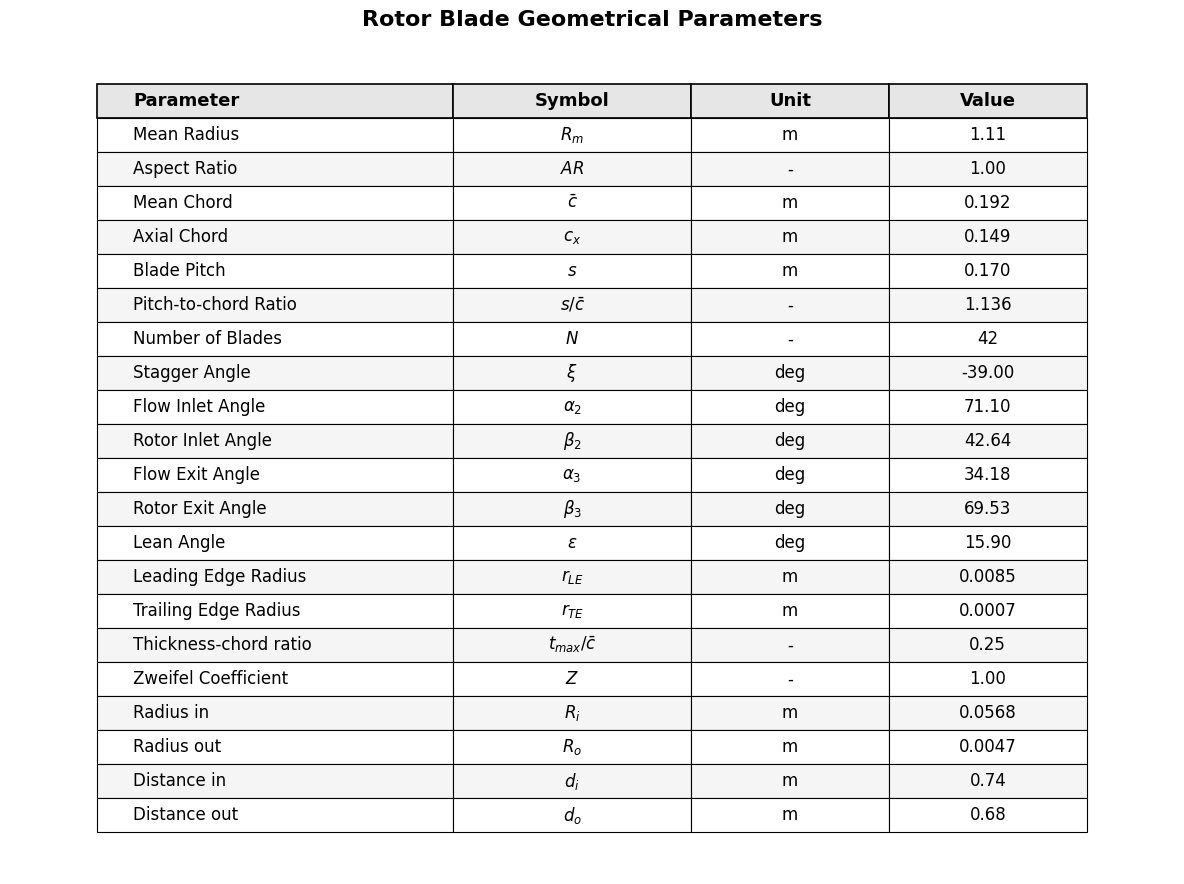

In [18]:
# ============================================================
# PART 3 — ROTOR BLADE DESIGN (REPORT + PARABLADE READY)
# ============================================================

# ==============================
# INPUT FROM PART 1–2
# ==============================

H2 = height_2                 # Blade span at rotor inlet [m]
H3 = height_3                 # Blade span at rotor exit  [m]
Dm = D_m2                     # Mean diameter at rotor    [m]

beta2 = stats_final["beta2"]  # Rotor inlet relative angle [deg]
beta3 = stats_final["beta3"]  # Rotor exit relative angle  [deg]
alpha2 = stats_final["alpha2"]  # Stator/flow inlet angle  [deg]
alpha3 = stats_final["alpha3"]  # Flow exit angle           [deg]

# ==============================
# USER DESIGN CHOICES
# ==============================

AR = 1.0                      # Aspect ratio (H / Cx)
Z  = 1.0                      # Zweifel coefficient (MANDATORY from brief)
stag_angle_deg = 39           # Stagger angle [deg]

tmax_C_ratio = 0.25           # Maximum thickness ratio
TEradius = 0.0007             # Trailing edge radius [m]
LEradius_percent = 0.05       # Leading edge radius as % of pitch

# ==============================
# 1) CHORD FROM ASPECT RATIO
# ==============================

# Chords from AR and stag angle
chord = height_2/AR
Cx = np.cos(np.deg2rad(stag_angle_deg))*chord
epsilon = np.rad2deg(np.arctan((H3 - H2) / Cx)) #lean angle


# ==============================
# 2) ZWEIFEL PITCH & BLADE COUNT
# ==============================

s_over_Cx = Z / (2 * np.cos(np.deg2rad(beta3))**2 *(np.tan(np.deg2rad(beta3)) + np.tan(np.deg2rad(beta2))))

# KEEP ZWEIFEL PITCH — DO NOT RECOMPUTE IT
pitch = (Z*Cx) / (2 * (np.cos(np.deg2rad(beta3))**2)
                  * (np.tan(np.deg2rad(beta3)) + np.tan(np.deg2rad(beta2))))

N_blades = np.ceil((np.pi*Dm)/pitch)    # report-only

s_over_Cx = pitch / Cx
s_over_C  = pitch / chord

# ==============================
# 4) LEADING & TRAILING EDGE
# ==============================

LEradius = LEradius_percent * pitch
t_max = tmax_C_ratio * Cx
LE_prcent_of_Cx     =LEradius/Cx
TE_prcent_of_Cx     =TEradius/Cx 
# ==============================
# 5) FLOW & NORMAL VECTORS (FOR PARABLADE)
# ==============================
flow_dir_x = np.cos(np.deg2rad(beta2))
flow_dir_y = np.sin(np.deg2rad(beta2))



# ==============================
# 6) TABLE
# ==============================

table_data = [
    ["Mean Radius",           r"$R_m$",        "m",   f"{R_mean:.2f}"],
    ["Aspect Ratio",         r"$AR$",         "-",   f"{AR:.2f}"],
    ["Mean Chord", r"$\bar{c}$", "m", f"{chord:.3f}"],
    ["Axial Chord",          r"$c_x$",        "m",   f"{Cx:.3f}"],
    ["Blade Pitch",          r"$s$",          "m",   f"{pitch:.3f}"],
    ["Pitch-to-chord Ratio",          r"$s/\bar{c}$",          "-",   f"{s_over_Cx:.3f}"],
    ["Number of Blades",     r"$N$",          "-",   f"{int(N_blades)}"],
    ["Stagger Angle",        r"$\xi$",     "deg", f"{-stag_angle_deg:.2f}"],
    ["Flow Inlet Angle",    r"$\alpha_2$",    "deg", f"{alpha2:.2f}"],
    ["Rotor Inlet Angle",    r"$\beta_2$",    "deg", f"{beta2:.2f}"],
    ["Flow Exit Angle",     r"$\alpha_3$",    "deg", f"{alpha3:.2f}"],
    ["Rotor Exit Angle",     r"$\beta_3$",    "deg", f"{beta3:.2f}"],
    ["Lean Angle",           r"$\epsilon$",   "deg", f"{epsilon:.2f}"],
    ["Leading Edge Radius",  r"$r_{LE}$",     "m",   f"{LEradius:.4f}"],
    ["Trailing Edge Radius", r"$r_{TE}$",     "m",   f"{TEradius:.4f}"],
    ["Thickness-chord ratio",        r"$t_{max}/\bar{c}$",    "-",   f"{tmax_C_ratio}"],
    ["Zweifel Coefficient",  r"$Z$",          "-",   f"{Z:.2f}"],
    ["Radius in",  r"$R_i$",          "m",   f"{LE_prcent_of_Cx:.4f}"],
    ["Radius out",  r"$R_o$",          "m",   f"{TE_prcent_of_Cx:.4f}"],
    ["Distance in",  r"$d_i$",          "m",   f"{flow_dir_x:.2f}"],
    ["Distance out",  r"$d_o$",          "m",   f"{flow_dir_y:.2f}"],
]

columns = ["Parameter", "Symbol", "Unit", "Value"]
df = pd.DataFrame(table_data, columns=columns)

# ---------------------------
# MATPLOTLIB TABLE PLOTTING
# ---------------------------
fig, ax = plt.subplots(figsize=(12, 9))

ax.axis("off")

tbl = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    loc="center",
    cellLoc="center",
    colWidths=[0.18, 0.12, 0.1, 0.10]
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1.7, 1.7)

# ---------------------------
# STYLING
# ---------------------------

for (row, col), cell in tbl.get_celld().items():

    # Header row
    if row == 0:
        cell.set_facecolor("#e6e6e6")
        cell.set_text_props(weight="bold", fontsize=13)
        cell.set_linewidth(1.2)

    else:
        cell.set_linewidth(0.8)

        # Alternate row shading
        if row % 2 == 0:
            cell.set_facecolor("#f5f5f5")

    # Left-align Parameter column
    if col == 0:
        cell.set_text_props(ha="left")

plt.title(
    "Rotor Blade Geometrical Parameters",
    fontsize=16,
    fontweight="bold",
    pad=12
)

plt.tight_layout()
save_path = os.path.join(RESULTS, "Rotor Blade Geometrical Parameters.png")

plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

	Check the the curvature given as a design variable matches with the output curvature:
               Point 	      Design variable    	 Upper surface analytic    	 Lower surface analytic
               Start 	          1.76089e+01 	          1.76089e+01 	          1.76089e+01
                 End 	          2.13293e+02 	          2.13293e+02 	          2.13293e+02


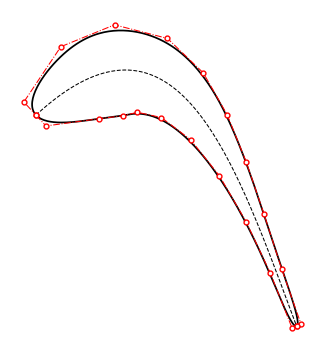

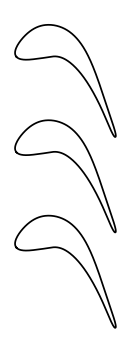

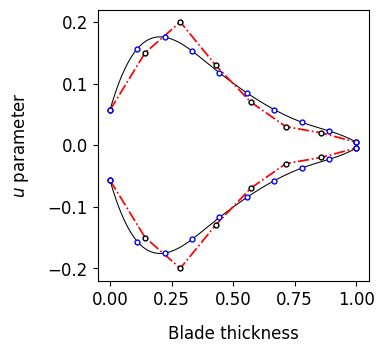

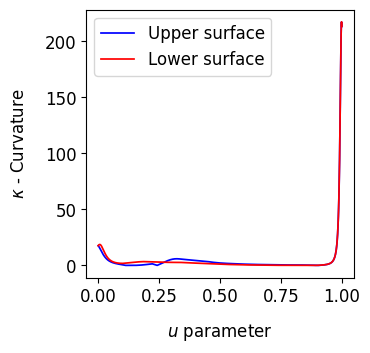

In [19]:
import sys

sys.path.append("/Users/sanju/Projects/Python/Turbine Stage Design/parablade-master/parablade")

from parablade.blade_2D_camber_thickness import Blade2DCamberThickness

design_variables = {}

design_variables['stagger']    = - stag_angle_deg          # stagger γ
design_variables['theta_in']   = beta2                   # β2
design_variables['theta_out']  = -beta3                  # sign as in your colleague's script

# non-dimensional radii (r / Cx)
design_variables['radius_in']  = LEradius / Cx
design_variables['radius_out'] = TEradius / Cx

# camber-line station positions
design_variables['dist_in']  = flow_dir_x
design_variables['dist_out'] = flow_dir_y

# thickness distributions (non-dimensional)
design_variables['thickness_upper_1'] = 0.15
design_variables['thickness_upper_2'] = 0.20
design_variables['thickness_upper_3'] = 0.13
design_variables['thickness_upper_4'] = 0.07
design_variables['thickness_upper_5'] = 0.03
design_variables['thickness_upper_6'] = 0.02
design_variables['thickness_lower_1'] = 0.15
design_variables['thickness_lower_2'] = 0.20
design_variables['thickness_lower_3'] = 0.13
design_variables['thickness_lower_4'] = 0.07
design_variables['thickness_lower_5'] = 0.03
design_variables['thickness_lower_6'] = 0.02

# Convert standard-python scalars into singleton numpy arrays
for i in design_variables:
    design_variables[i] = np.asarray(design_variables[i])

u = np.linspace(0.00, 1.00, 1000)
my_blade = Blade2DCamberThickness(design_variables)
my_blade.get_section_coordinates(u)
my_blade.check_analytic_curvature()

#----------------------------------------------------------------------------------------------------------------------#
# Plot the 2D section
#----------------------------------------------------------------------------------------------------------------------#
# Plot a single blade
my_blade.plot_blade_section(upper_side='yes', upper_side_control_points='yes',
                            lower_side='yes', lower_side_control_points='yes',
                            camberline='yes', camberline_control_points='no', camberline_sample_points='no',
                            leading_edge_radius='no', trailing_edge_radius='no')

save_path = os.path.join(RESULTS, "Blade Section.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# Plot a cascade of blades
my_blade.plot_blade_cascade()
save_path = os.path.join(RESULTS, "Blade Cascade.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# Plot the thickness distribution
my_blade.plot_thickness_distribution()
save_path = os.path.join(RESULTS, "Thickness Distribution.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# Plot the curvature distribution
my_blade.plot_curvature_distribution()
save_path = os.path.join(RESULTS, "Curvature Distribution.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# Show the figure


plt.show()



## PART 4 — Blade Passage Geometry

Using the ParaBlade blade section generated in Part 3, we construct the **blade passage** by placing two adjacent blades separated by the design pitch `s`. The passage is bounded by:
- The **suction (upper) surface** of blade 1
- The **pressure (lower) surface** of blade 2, offset by `s/Cx` in the pitchwise direction

The **geometric throat** `o` is the minimum gap across the passage (approximately perpendicular to the suction surface near the trailing edge).


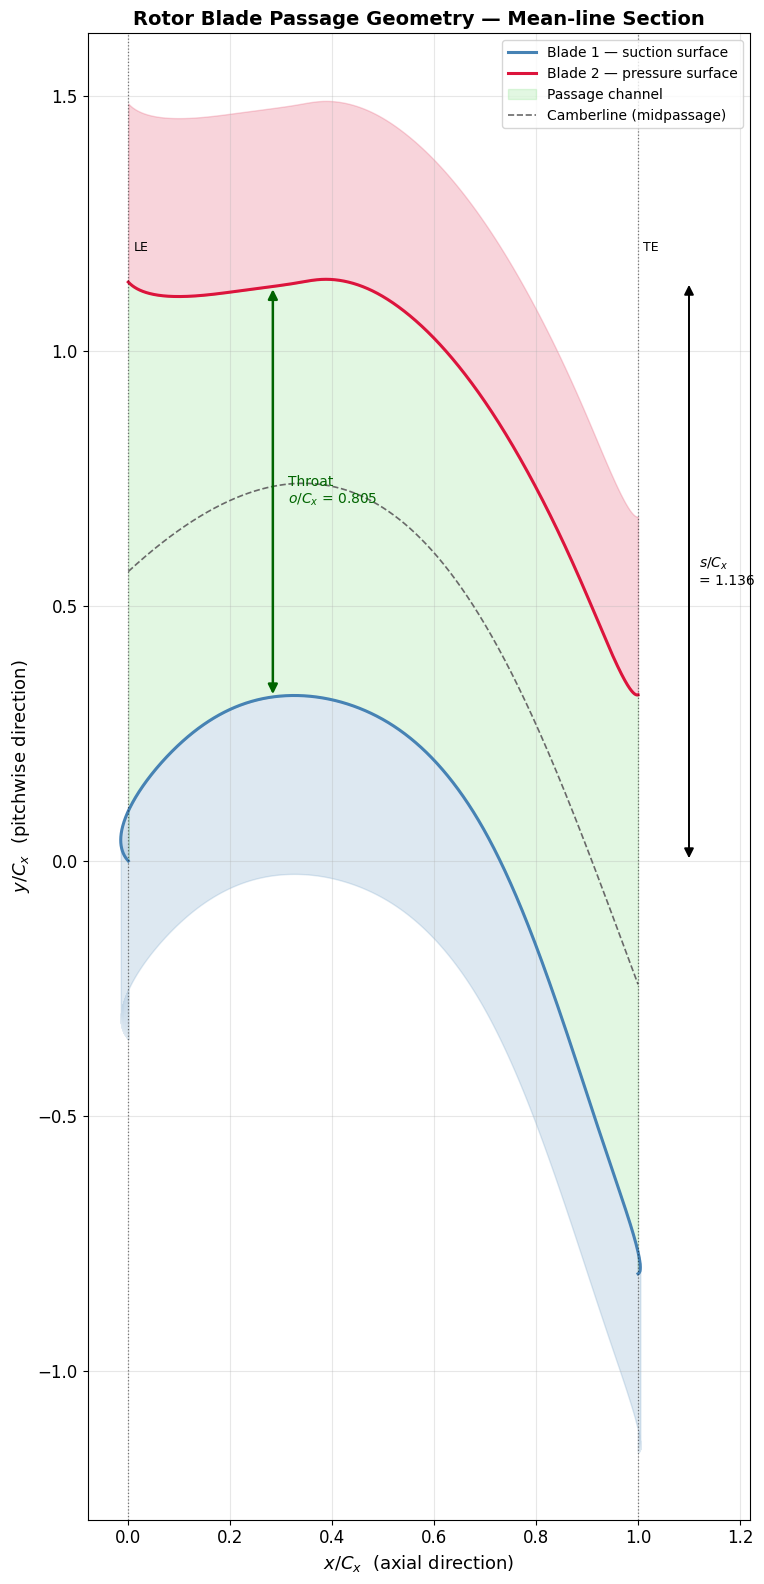

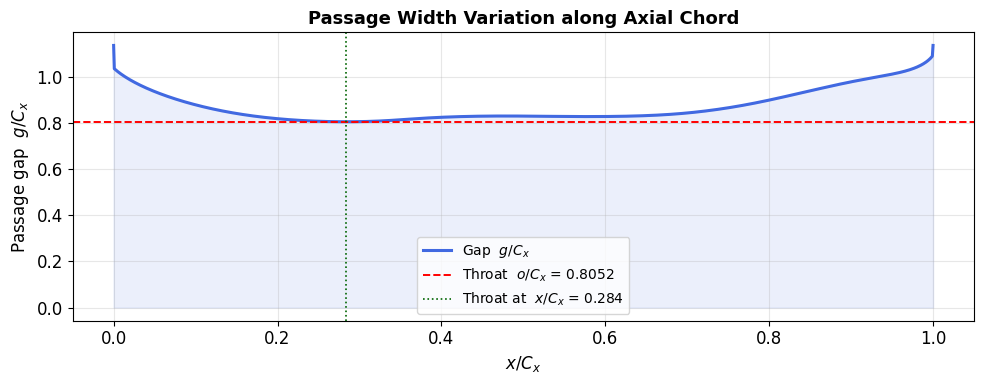


========== BLADE PASSAGE GEOMETRY SUMMARY ==========
Non-dimensional pitch      s / Cx   = 1.1358
Geometric throat           o / Cx   = 0.8052
Throat axial location      x / Cx   = 0.2836
Throat-to-pitch ratio      o / s    = 0.7090

Axial chord                Cx       = 0.1493 m
Dimensional pitch          s        = 0.1696 m
Dimensional throat         o        = 0.1202 m
Number of rotor blades     N        = 42



In [20]:
# ============================================================
# PART 4 — BLADE PASSAGE GEOMETRY (ParaBlade)
# ============================================================

from scipy.interpolate import interp1d

u_fine = np.linspace(0.0, 1.0, 2000)

# -------------------------------------------------------
# 1) Extract coordinates (non-dimensional, normalised by Cx)
# -------------------------------------------------------
us = np.real(my_blade.get_upper_side_coordinates(u_fine))  # (2, N) suction surface
ls = np.real(my_blade.get_lower_side_coordinates(u_fine))  # (2, N) pressure surface
cl = np.real(my_blade.get_camberline_coordinates(u_fine))  # (2, N) camberline

# Non-dimensional pitch (already computed in Part 3)
s_Cx = s_over_Cx

# -------------------------------------------------------
# 2) Sort by x for monotone interpolation
# -------------------------------------------------------
us_s = us[:, np.argsort(us[0, :])]
ls_s = ls[:, np.argsort(ls[0, :])]

x_lo = max(us_s[0, 0],  ls_s[0, 0])
x_hi = min(us_s[0, -1], ls_s[0, -1])
x_c  = np.linspace(x_lo, x_hi, 1200)

y_suc  = interp1d(us_s[0,:], us_s[1,:], kind='linear')(x_c)         # suction surface
y_pres = interp1d(ls_s[0,:], ls_s[1,:], kind='linear')(x_c) + s_Cx  # pressure surface of adjacent blade

gap = y_pres - y_suc    # passage width g/Cx at each axial station

# -------------------------------------------------------
# 3) Geometric throat (minimum gap)
# -------------------------------------------------------
i_thr  = int(np.argmin(gap))
x_thr  = x_c[i_thr]
g_thr  = gap[i_thr]
y_tmid = 0.5 * (y_suc[i_thr] + y_pres[i_thr])

# -------------------------------------------------------
# 4) FIGURE 1 — Blade Passage
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 16))

# Blade 1 suction surface (blue)
ax.plot(us[0,:], us[1,:], color='steelblue', linewidth=2.2,
        label='Blade 1 — suction surface')

# Fill blade 1 body (below suction surface, symbolic)
ax.fill_between(us_s[0,:], us_s[1,:] - 0.35, us_s[1,:],
                color='steelblue', alpha=0.18)

# Blade 2 pressure surface (red), shifted by pitch
ax.plot(ls[0,:], ls[1,:] + s_Cx, color='crimson', linewidth=2.2,
        label='Blade 2 — pressure surface')

# Fill blade 2 body (above pressure surface, symbolic)
ax.fill_between(ls_s[0,:], ls_s[1,:] + s_Cx, ls_s[1,:] + s_Cx + 0.35,
                color='crimson', alpha=0.18)

# Shade the passage channel
ax.fill_between(x_c, y_suc, y_pres, alpha=0.14, color='limegreen', label='Passage channel')

# Camberline at pitch midpoint
ax.plot(cl[0,:], cl[1,:] + s_Cx / 2.0, linestyle='--', color='dimgray',
        linewidth=1.2, label='Camberline (midpassage)')

# Throat double-headed arrow
ax.annotate('', xy=(x_thr, y_pres[i_thr]), xytext=(x_thr, y_suc[i_thr]),
            arrowprops=dict(arrowstyle='<|-|>', color='darkgreen',
                            lw=1.8, mutation_scale=14))
ax.text(x_thr + 0.03, y_tmid,
        f'Throat\n$o/C_x$ = {g_thr:.3f}',
        color='darkgreen', fontsize=10, va='center')

# Pitch annotation on right
ax.annotate('', xy=(1.10, s_Cx), xytext=(1.10, 0.0),
            arrowprops=dict(arrowstyle='<|-|>', color='black',
                            lw=1.4, mutation_scale=14))
ax.text(1.12, s_Cx / 2.0,
        f'$s/C_x$\n= {s_Cx:.3f}',
        fontsize=10, va='center')

# LE / TE guide lines
for xv, lbl in [(0.0, 'LE'), (1.0, 'TE')]:
    ax.axvline(xv, color='k', linestyle=':', linewidth=0.9, alpha=0.5)
    ax.text(xv + 0.01, s_Cx + 0.06, lbl, fontsize=9, color='black')

ax.set_xlim(-0.08, 1.22)
ax.set_xlabel(r'$x / C_x$  (axial direction)', fontsize=13)
ax.set_ylabel(r'$y / C_x$  (pitchwise direction)', fontsize=13)
ax.set_title('Rotor Blade Passage Geometry — Mean-line Section', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()

save_path = os.path.join(RESULTS, "Rotor Blade Passage Geometry.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

# -------------------------------------------------------
# 5) FIGURE 2 — Passage width variation
# -------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(10, 4))

ax2.plot(x_c, gap, color='royalblue', linewidth=2.2, label=r'Gap  $g/C_x$')
ax2.axhline(g_thr, color='red', linestyle='--', linewidth=1.4,
            label=f'Throat  $o/C_x$ = {g_thr:.4f}')
ax2.axvline(x_thr, color='darkgreen', linestyle=':', linewidth=1.2,
            label=f'Throat at  $x/C_x$ = {x_thr:.3f}')
ax2.fill_between(x_c, 0, gap, alpha=0.10, color='royalblue')

ax2.set_xlabel(r'$x / C_x$', fontsize=12)
ax2.set_ylabel(r'Passage gap  $g / C_x$', fontsize=12)
ax2.set_title('Passage Width Variation along Axial Chord', fontsize=13, fontweight='bold')
ax2.legend(loc='lower center', fontsize=10)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
save_path = os.path.join(RESULTS, "Passage Width Variation.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

# -------------------------------------------------------
# 6) Summary
# -------------------------------------------------------
o_thr_dim = g_thr * Cx

print("\n========== BLADE PASSAGE GEOMETRY SUMMARY ==========")
print(f"Non-dimensional pitch      s / Cx   = {s_Cx:.4f}")
print(f"Geometric throat           o / Cx   = {g_thr:.4f}")
print(f"Throat axial location      x / Cx   = {x_thr:.4f}")
print(f"Throat-to-pitch ratio      o / s    = {(g_thr / s_Cx):.4f}")
print(f"")
print(f"Axial chord                Cx       = {Cx:.4f} m")
print(f"Dimensional pitch          s        = {pitch:.4f} m")
print(f"Dimensional throat         o        = {o_thr_dim:.4f} m")
print(f"Number of rotor blades     N        = {int(N_blades)}")
print("=====================================================\n")


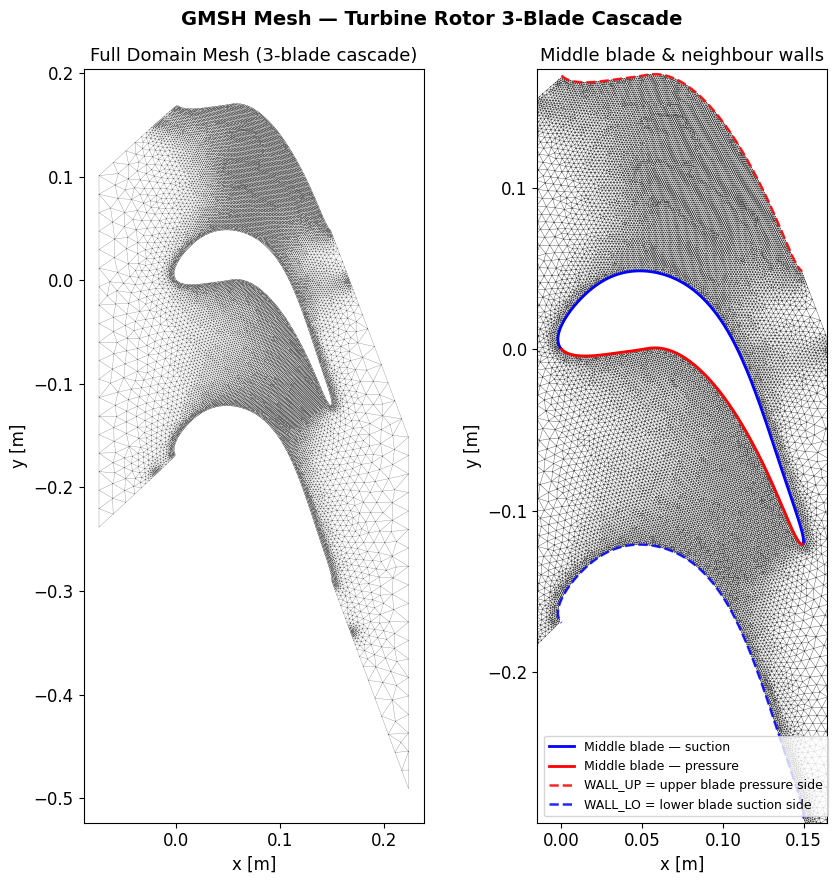

Nodes : 18146
Cells : 35389
x range: -0.0747 → 0.2240 m
y range: -0.4905 → 0.1704 m


In [21]:
# ── Mesh quality check (three-blade cascade) ───────────────────────────────
import pyvista as pv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

mesh = pv.read('/Users/sanju/Projects/Python/Turbine Stage Design/flow.vtu')

mesh_tri = mesh.triangulate()
cells = mesh_tri.cells.reshape(-1, 4)
tris  = cells[:, 1:]
xm    = mesh_tri.points[:, 0]
ym    = mesh_tri.points[:, 1]
triang = mtri.Triangulation(xm, ym, tris)

# ── Blade surfaces (middle blade) ─────────────────────────────────────────
_N  = 600
_u  = np.linspace(0.0, 1.0, _N)
_us = np.real(my_blade.get_upper_side_coordinates(_u))
_ls = np.real(my_blade.get_lower_side_coordinates(_u))
xs_us = _us[0, :] * Cx;  ys_us = _us[1, :] * Cx   # suction
xs_ls = _ls[0, :] * Cx;  ys_ls = _ls[1, :] * Cx   # pressure
LE_x, LE_y = float(xs_us[-1]), float(ys_us[-1])
TE_x, TE_y = float(xs_us[0]),  float(ys_us[0])

fig, axes = plt.subplots(1, 2, figsize=(9, 9))

# ── Left: full domain mesh ────────────────────────────────────────────────
axes[0].triplot(triang, 'k-', lw=0.2, alpha=0.6)
axes[0].set_aspect('equal')
axes[0].set_title('Full Domain Mesh (3-blade cascade)', fontsize=13)
axes[0].set_xlabel('x [m]');  axes[0].set_ylabel('y [m]')

# ── Right: middle blade + neighbour walls ─────────────────────────────────
axes[1].triplot(triang, 'k-', lw=0.3, alpha=0.7)
axes[1].plot(xs_us, ys_us, 'b-', lw=2, label='Middle blade — suction')
axes[1].plot(xs_ls, ys_ls, 'r-', lw=2, label='Middle blade — pressure')
axes[1].plot(xs_ls, ys_ls + pitch, 'r--', lw=1.8, alpha=0.85,
             label='WALL_UP = upper blade pressure side')
axes[1].plot(xs_us, ys_us - pitch, 'b--', lw=1.8, alpha=0.85,
             label='WALL_LO = lower blade suction side')

x_lo = LE_x - 0.10 * Cx
x_hi = TE_x + 0.10 * Cx
y_lo = (ys_us - pitch).min() - 0.02 * Cx
y_hi = (ys_ls + pitch).max() + 0.02 * Cx
axes[1].set_xlim([x_lo, x_hi]);  axes[1].set_ylim([y_lo, y_hi])
axes[1].set_aspect('equal')
axes[1].set_title('Middle blade & neighbour walls', fontsize=13)
axes[1].set_xlabel('x [m]');  axes[1].set_ylabel('y [m]')
axes[1].legend(fontsize=9, loc='lower left')

plt.suptitle('GMSH Mesh — Turbine Rotor 3-Blade Cascade', fontsize=14, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(RESULTS, "Blade-mesh.png")
plt.savefig(save_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'Nodes : {mesh.n_points}')
print(f'Cells : {mesh.n_cells}')
print(f'x range: {xm.min():.4f} → {xm.max():.4f} m')
print(f'y range: {ym.min():.4f} → {ym.max():.4f} m')


Inlet  height = 339.2 mm
Outlet height = 339.2 mm   (both ~ 2 pitch = 339.2 mm)


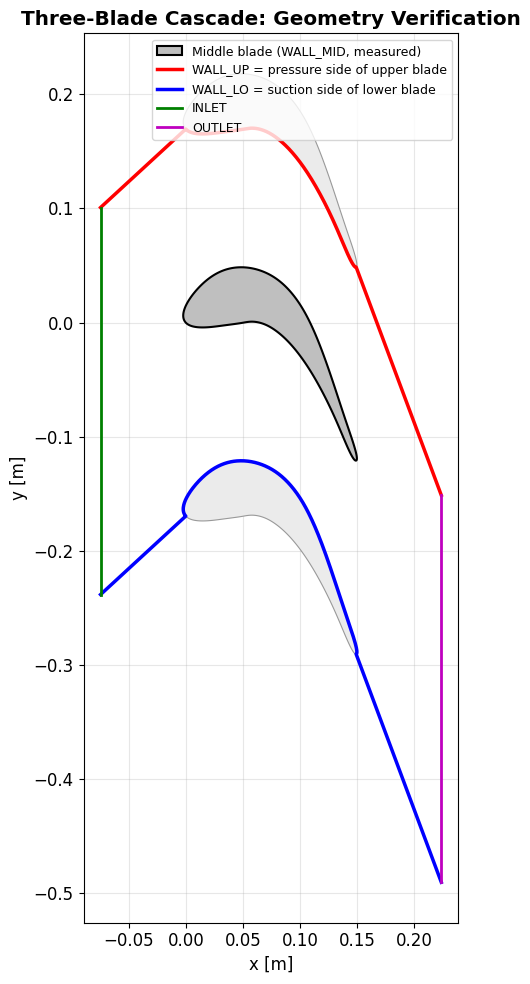

In [22]:
# ============================================================
# PART 5a (pre-check) — Geometry Verification (3-blade cascade)
# Run BEFORE the GMSH cell. Pure numpy/matplotlib — no GMSH needed.
# Mirrors the EXACT domain built in the GMSH cell so the mesh can be
# previewed: middle blade (WALL_MID) + the two neighbour walls + planes.
#   WALL_UP = pressure side of upper blade  (= B0 pressure + pitch)
#   WALL_LO = suction  side of lower blade  (= B0 suction  - pitch)
# Inlet/outlet walls are extended along the flow angles +beta2 / -beta3
# (the relative flow ENTERS at +beta2 and LEAVES at -beta3, i.e. downward).
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

_N  = 600
_u  = np.linspace(0.0, 1.0, _N)
_us = np.real(my_blade.get_upper_side_coordinates(_u))   # suction
_ls = np.real(my_blade.get_lower_side_coordinates(_u))   # pressure
_xsu, _ysu = _us[0] * Cx, _us[1] * Cx
_xsl, _ysl = _ls[0] * Cx, _ls[1] * Cx
_LEx, _TEx = float(_xsu[-1]), float(_xsu[0])             # u=1 -> LE,  u=0 -> TE

# middle blade closed loop (display only).
# parablade returns suction TE->LE and pressure LE->TE (opposite senses),
# so concatenating them as-is traces the perimeter once and closes cleanly.
_bx = np.r_[_xsu, _xsl]
_by = np.r_[_ysu, _ysl]

# neighbour walls, BOTH ordered LE -> TE (increasing x) so the stitched
# path [inlet, wall, outlet] stays in order
_uw = np.column_stack([_xsl,       _ysl + pitch])         # upper wall = pressure(+pitch)
_lw = np.column_stack([_xsu[::-1], _ysu[::-1] - pitch])   # lower wall = suction(-pitch)

# flow-aligned extensions to the inlet / outlet planes
_xin, _xout = _LEx - 0.5 * Cx, _TEx + 0.5 * Cx
_si =  np.tan(np.radians(beta2))     # inlet  flow angle  (+beta2)
_so = -np.tan(np.radians(beta3))     # outlet flow angle  (-beta3): flow leaves DOWNWARD
_ext_in  = lambda p: np.array([_xin,  p[1] + _si * (_xin  - p[0])])   # extend LE end upstream
_ext_out = lambda p: np.array([_xout, p[1] + _so * (_xout - p[0])])   # extend TE end downstream
_uw_f = np.vstack([_ext_in(_uw[0]), _uw, _ext_out(_uw[-1])])
_lw_f = np.vstack([_ext_in(_lw[0]), _lw, _ext_out(_lw[-1])])

print(f'Inlet  height = {(_uw_f[0, 1]  - _lw_f[0, 1]) * 1e3:.1f} mm')
print(f'Outlet height = {(_uw_f[-1, 1] - _lw_f[-1, 1]) * 1e3:.1f} mm   (both ~ 2 pitch = {2 * pitch * 1e3:.1f} mm)')

fig, ax = plt.subplots(figsize=(12, 10))
ax.fill(_bx, _by, color='0.75', ec='k', lw=1.5, label='Middle blade (WALL_MID, measured)', zorder=4)
# neighbour blade bodies (ghosted) one pitch up / down
ax.fill(_bx, _by + pitch, color='0.92', ec='0.6', lw=0.8, zorder=2)
ax.fill(_bx, _by - pitch, color='0.92', ec='0.6', lw=0.8, zorder=2)
# the two walls actually used (faces of the neighbour blades) + flow-aligned extensions
ax.plot(_uw_f[:, 0], _uw_f[:, 1], 'r-', lw=2.5, label='WALL_UP = pressure side of upper blade')
ax.plot(_lw_f[:, 0], _lw_f[:, 1], 'b-', lw=2.5, label='WALL_LO = suction side of lower blade')
ax.plot([_xin,  _xin ], [_lw_f[0, 1],  _uw_f[0, 1] ], 'g-', lw=2, label='INLET')
ax.plot([_xout, _xout], [_uw_f[-1, 1], _lw_f[-1, 1]], 'm-', lw=2, label='OUTLET')
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
ax.set_title('Three-Blade Cascade: Geometry Verification', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
save_path = os.path.join(RESULTS, "Mesh-geo-verification.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

In [23]:
# ============================================================
# PART 5a — GMSH: Three-Blade Cascade Passage Mesh
# ============================================================
# The linear cascade is modelled as THREE blades (no periodicity):
#
#   WALL_MID = the MIDDLE rotor blade  -> the body we measure around
#   WALL_UP  = pressure side of the UPPER blade  (= B0 pressure + pitch)
#   WALL_LO  = suction  side of the LOWER blade  (= B0 suction  - pitch)
#   INLET    = vertical line joining the two walls' upstream ends
#   OUTLET   = vertical line joining the two walls' downstream ends
#
# The middle blade sees one full real passage above it (bounded by the upper
# blade's pressure side) and one below it (bounded by the lower blade's suction
# side).  The neighbour surfaces are solid walls, like a 3-blade test section.
# ============================================================
try:
    gmsh.finalize()
except Exception:
    pass

import gmsh
import numpy as np
import os

WORK_DIR = '/Users/sanju/Projects/Python/Turbine Stage Design'

# ── Middle-blade coordinates ──────────────────────────────────────────────────
N_surf = 600
STRIDE = 4
u_s  = np.linspace(0.0, 1.0, N_surf)
us_n = np.real(my_blade.get_upper_side_coordinates(u_s))   # suction
ls_n = np.real(my_blade.get_lower_side_coordinates(u_s))   # pressure
xs_us, ys_us = us_n[0, :] * Cx, us_n[1, :] * Cx
xs_ls, ys_ls = ls_n[0, :] * Cx, ls_n[1, :] * Cx
LE_x, LE_y = float(xs_us[-1]), float(ys_us[-1])    # u=1 -> LE
TE_x, TE_y = float(xs_us[0]),  float(ys_us[0])     # u=0 -> TE

# ── Neighbour walls (both ordered LE -> TE, i.e. increasing x) ─────────────────
uw = np.column_stack([xs_ls,       ys_ls + pitch])   # UPPER wall = pressure(+pitch)
lw = np.column_stack([xs_us[::-1], ys_us[::-1] - pitch])  # LOWER wall = suction(-pitch)

# ── Middle-blade camber line (for the post-processing probes) ─────────────────
xg  = np.linspace(LE_x, TE_x, 400)
ysc = np.interp(xg, xs_us[np.argsort(xs_us)], ys_us[np.argsort(xs_us)])
ypr = np.interp(xg, xs_ls[np.argsort(xs_ls)], ys_ls[np.argsort(xs_ls)])
cam = np.column_stack([xg, 0.5 * (ysc + ypr)])

# ── Inlet / outlet extensions along the flow angles beta2 / beta3 ─────────────
EXT_IN, EXT_OUT = 0.5 * Cx, 0.5 * Cx
x_in, x_out = LE_x - EXT_IN, TE_x + EXT_OUT
_si = np.tan(np.radians(beta2))
_so = -np.tan(np.radians(beta3))     # flow LEAVES at -beta3 (downward)
_up = lambda p: np.array([x_in,  p[1] + _si * (x_in  - p[0])])
_dn = lambda p: np.array([x_out, p[1] + _so * (x_out - p[0])])
uw_f    = np.vstack([_up(uw[0]),  uw,  _dn(uw[-1])])
lw_f    = np.vstack([_up(lw[0]),  lw,  _dn(lw[-1])])
cam_ext = np.vstack([_up(cam[0]), cam, _dn(cam[-1])])
domain_height = pitch

def camber_y(xq):
    """Middle-blade camber-line y at axial position xq (used by post-processing)."""
    return np.interp(xq, cam_ext[:, 0], cam_ext[:, 1])

print(f'Middle blade:  LE = ({LE_x*1e3:.2f}, {LE_y*1e3:.2f}) mm   TE = ({TE_x*1e3:.2f}, {TE_y*1e3:.2f}) mm')
print(f'Inlet height = {(uw_f[0,1]-lw_f[0,1])*1e3:.1f} mm   Outlet height = {(uw_f[-1,1]-lw_f[-1,1])*1e3:.1f} mm  (~2 pitch)')
print(f'pitch = {pitch*1e3:.3f} mm   Cx = {Cx*1e3:.3f} mm   x_in = {x_in*1e3:.1f}  x_out = {x_out*1e3:.1f} mm')

# ── GMSH build ────────────────────────────────────────────────────────────────
gmsh.initialize()
gmsh.model.add('cascade_3blade')
geo = gmsh.model.geo
lc  = Cx / 8

def _add(arr):
    return [geo.addPoint(float(p[0]), float(p[1]), 0, lc) for p in arr]

pLi = geo.addPoint(float(lw_f[0, 0]),  float(lw_f[0, 1]),  0, lc)   # lower wall, inlet end
pLo = geo.addPoint(float(lw_f[-1, 0]), float(lw_f[-1, 1]), 0, lc)   # lower wall, outlet end
pUi = geo.addPoint(float(uw_f[0, 0]),  float(uw_f[0, 1]),  0, lc)   # upper wall, inlet end
pUo = geo.addPoint(float(uw_f[-1, 0]), float(uw_f[-1, 1]), 0, lc)   # upper wall, outlet end
pLE = geo.addPoint(LE_x, LE_y, 0, lc)
pTE = geo.addPoint(TE_x, TE_y, 0, lc)

sp_lw  = geo.addBSpline([pLi] + _add(lw_f[1:-1:STRIDE]) + [pLo])    # lower wall  x_in -> x_out
sp_uw  = geo.addBSpline([pUi] + _add(uw_f[1:-1:STRIDE]) + [pUo])    # upper wall  x_in -> x_out
sp_suc = geo.addBSpline([pTE] + _add(np.column_stack([xs_us, ys_us])[STRIDE:N_surf - STRIDE:STRIDE]) + [pLE])
sp_pre = geo.addBSpline([pLE] + _add(np.column_stack([xs_ls, ys_ls])[STRIDE:N_surf - STRIDE:STRIDE]) + [pTE])

l_inlet  = geo.addLine(pLi, pUi)    # inlet  : lower -> upper
l_outlet = geo.addLine(pUo, pLo)    # outlet : upper -> lower

# Outer loop (CCW): lower wall L->R, outlet up, upper wall R->L, inlet down
outer_cl = geo.addCurveLoop([sp_lw, -l_outlet, -sp_uw, -l_inlet])
blade_cl = geo.addCurveLoop([-sp_suc, -sp_pre])     # middle blade (interior hole)
surf = geo.addPlaneSurface([outer_cl, blade_cl])
geo.synchronize()

gmsh.model.addPhysicalGroup(1, [l_inlet],          name='INLET')
gmsh.model.addPhysicalGroup(1, [l_outlet],         name='OUTLET')
gmsh.model.addPhysicalGroup(1, [sp_uw],            name='WALL_UP')   # pressure side of upper blade
gmsh.model.addPhysicalGroup(1, [sp_lw],            name='WALL_LO')   # suction  side of lower blade
gmsh.model.addPhysicalGroup(1, [sp_suc, sp_pre],   name='WALL_MID')  # middle blade (measured)
gmsh.model.addPhysicalGroup(2, [surf],             name='FLUID')

# ── Size field: fine near all blade walls, coarse mid-passage ─────────────────
dist_f = gmsh.model.mesh.field.add('Distance')
gmsh.model.mesh.field.setNumbers(dist_f, 'CurvesList', [sp_suc, sp_pre, sp_uw, sp_lw])
gmsh.model.mesh.field.setNumber(dist_f, 'Sampling', 400)
thr_f = gmsh.model.mesh.field.add('Threshold')
gmsh.model.mesh.field.setNumber(thr_f, 'InField', dist_f)
gmsh.model.mesh.field.setNumber(thr_f, 'SizeMin', Cx / 110)
gmsh.model.mesh.field.setNumber(thr_f, 'SizeMax', Cx / 7)
gmsh.model.mesh.field.setNumber(thr_f, 'DistMin', 0.004)
gmsh.model.mesh.field.setNumber(thr_f, 'DistMax', 0.050)
gmsh.model.mesh.field.setAsBackgroundMesh(thr_f)

print('\nGenerating 2-D mesh ...')
gmsh.model.mesh.generate(2)
node_tags, _, _ = gmsh.model.mesh.getNodes()
_, el_tags, _   = gmsh.model.mesh.getElements(dim=2)
print(f'Nodes    : {len(node_tags)}')
print(f'Elements : {sum(len(t) for t in el_tags)}')

su2_path = os.path.join(WORK_DIR, 'blade_mesh.su2')
msh_path = os.path.join(WORK_DIR, 'blade_mesh.msh')
gmsh.write(su2_path)
gmsh.write(msh_path)
gmsh.finalize()
print(f'SU2  -> {su2_path}')
print(f'GMSH -> {msh_path}')
print('\nDone - run Part 5b to write the SU2 config and simulate.')


Middle blade:  LE = (0.00, 0.00) mm   TE = (149.30, -120.90) mm
Inlet height = 339.2 mm   Outlet height = 339.2 mm  (~2 pitch)
pitch = 169.579 mm   Cx = 149.305 mm   x_in = -74.7  x_out = 224.0 mm

Generating 2-D mesh ...
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Nurb)
Info    : [ 20%] Meshing curve 2 (Nurb)
Info    : [ 40%] Meshing curve 3 (Nurb)
Info    : [ 60%] Meshing curve 4 (Nurb)
Info    : [ 70%] Meshing curve 5 (Line)
Info    : [ 90%] Meshing curve 6 (Line)
Info    : Done meshing 1D (Wall 0.0295589s, CPU 0.029158s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.193495s, CPU 0.184005s)
Info    : 18742 nodes 36894 elements
Nodes    : 18742
Elements : 35389
Info    : Writing '/Users/sanju/Projects/Python/Turbine Stage Design/blade_mesh.su2'...
Info    : Writing 35389 elements and 18146 nodes
Info    : Done writing '/Users/sanju/Projects/Python/Turbine Stage Design/blade_mesh.su2'
Info    : Writing '/U

In [24]:
# ============================================================
# PART 5b – SU2 Config + Run   (three-blade cascade, relative frame)
# ============================================================
import subprocess, os

WORK_DIR = '/Users/sanju/Projects/Python/Turbine Stage Design'
SU2_BIN  = '/Users/sanju/Downloads/bin/SU2_CFD'
CFG_FILE = os.path.join(WORK_DIR, 'blade_su2.cfg')

# Rotor solved in the RELATIVE frame as a fixed 3-blade cascade:
#   inlet  = relative total conditions (T0_rel, P0_rel, dir = (cos b2, sin b2, 0))
#   outlet = rotor exit static pressure P3
#   WALL_MID = no-slip viscous (measured);  WALL_UP/WALL_LO = inviscid slip (Euler)
cfg = f"""%%% SU2 configuration -- Turbine Rotor 3-Blade Cascade (relative frame)
SOLVER= RANS
KIND_TURB_MODEL= SA
MATH_PROBLEM= DIRECT
RESTART_SOL= NO

%%% FLUID PROPERTIES
FLUID_MODEL= IDEAL_GAS
GAMMA_VALUE= 1.3300
GAS_CONSTANT= 287.0000

%%% FREE-STREAM (relative-frame rotor inlet)
MACH_NUMBER= 0.3081
FREESTREAM_TEMPERATURE= 1553.73
FREESTREAM_PRESSURE= 1428997.01
AOA= 0.0
SIDESLIP_ANGLE= 0.0
INIT_OPTION= TD_CONDITIONS
REYNOLDS_NUMBER= 1.0E6
KIND_TRANS_MODEL= NONE

%%% REFERENCE VALUES
REF_LENGTH= {Cx:.8f}
REF_AREA= 0.0
REF_DIMENSIONALIZATION= DIMENSIONAL

%%% BOUNDARY CONDITIONS  (no periodicity — neighbour surfaces are walls)
INLET_TYPE= TOTAL_CONDITIONS
MARKER_INLET= (INLET, 1578.0609, 1521338.1450, 0.7356093167, 0.6774060327, 0.0)
MARKER_OUTLET= (OUTLET, 1107264.6278)
MARKER_HEATFLUX= (WALL_MID, 0.0)
MARKER_EULER= (WALL_UP, WALL_LO)
MARKER_PLOTTING= (WALL_MID)
MARKER_MONITORING= (WALL_MID)

%%% NUMERICS  (CFL ramp from 2 -> 50 for a robust start)
NUM_METHOD_GRAD= GREEN_GAUSS
CFL_NUMBER= 2.0
CFL_ADAPT= YES
CFL_ADAPT_PARAM= (0.1, 1.2, 0.5, 50.0)
CONV_NUM_METHOD_FLOW= JST
MUSCL_FLOW= NO
JST_SENSOR_COEFF= (0.5, 0.02)
TIME_DISCRE_FLOW= EULER_IMPLICIT
CONV_NUM_METHOD_TURB= SCALAR_UPWIND
MUSCL_TURB= NO
TIME_DISCRE_TURB= EULER_IMPLICIT
CFL_REDUCTION_TURB= 0.5

%%% LINEAR SOLVER
LINEAR_SOLVER= FGMRES
LINEAR_SOLVER_PREC= ILU
LINEAR_SOLVER_ERROR= 1E-4
LINEAR_SOLVER_ITER= 15

%%% CONVERGENCE
INNER_ITER= 4000
CONV_RESIDUAL_MINVAL= -9
CONV_STARTITER= 50
CONV_FIELD= RMS_DENSITY

%%% I/O
MESH_FILENAME= blade_mesh.su2
MESH_FORMAT= SU2
OUTPUT_FILES= (PARAVIEW, SURFACE_CSV, RESTART)
RESTART_FILENAME= restart_flow.dat
VOLUME_FILENAME= flow
SURFACE_FILENAME= surface_flow
CONV_FILENAME= history
SCREEN_WRT_FREQ_INNER= 250
OUTPUT_WRT_FREQ= 1000
"""

with open(CFG_FILE, 'w') as f:
    f.write(cfg)
print("Config written.")
print("  Walls   = WALL_MID (no-slip, measured) + WALL_UP/WALL_LO (Euler slip)")
print("  Mesh    = blade_mesh.su2")

# ── Run SU2 ───────────────────────────────────────────────────────────────────
print("\nLaunching SU2 — residual printed every 250 iterations ...\n")
proc = subprocess.Popen(
    [SU2_BIN, 'blade_su2.cfg'],
    cwd=WORK_DIR, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    text=True, bufsize=1,
)
for line in proc.stdout:
    print(line, end='')
proc.wait()
if proc.returncode == 0:
    print("\n✓ SU2 finished — flow.vtu and surface_flow.csv are ready.")
else:
    print(f"\n✗ SU2 exited with code {proc.returncode} — share any ERROR lines above.")


Config written.
  Walls   = WALL_MID (no-slip, measured) + WALL_UP/WALL_LO (Euler slip)
  Mesh    = blade_mesh.su2

Launching SU2 — residual printed every 250 iterations ...


-------------------------------------------------------------------------
|    ___ _   _ ___                                                      |
|   / __| | | |_  )   Release 8.5.0 "Harrier"                           |
|   \__ \ |_| |/ /                                                      |
|   |___/\___//___|   Suite (Computational Fluid Dynamics Code)         |
|                                                                       |
-------------------------------------------------------------------------
| SU2 Project Website: https://su2code.github.io                        |
|                                                                       |
| The SU2 Project is maintained by the SU2 Foundation                   |
| (http://su2foundation.org)                                            |
----------

Valid points after filter: 213 suction | 156 pressure


/var/folders/y4/vhllsfz10szd65q7tflb2pf40000gn/T/ipykernel_22169/1148835698.py:21: RuntimeWarning: invalid value encountered in sqrt
  M_is  = np.sqrt((2.0 / (gam - 1.0)) * ((P_t0 / P) ** ((gam - 1.0) / gam) - 1.0))


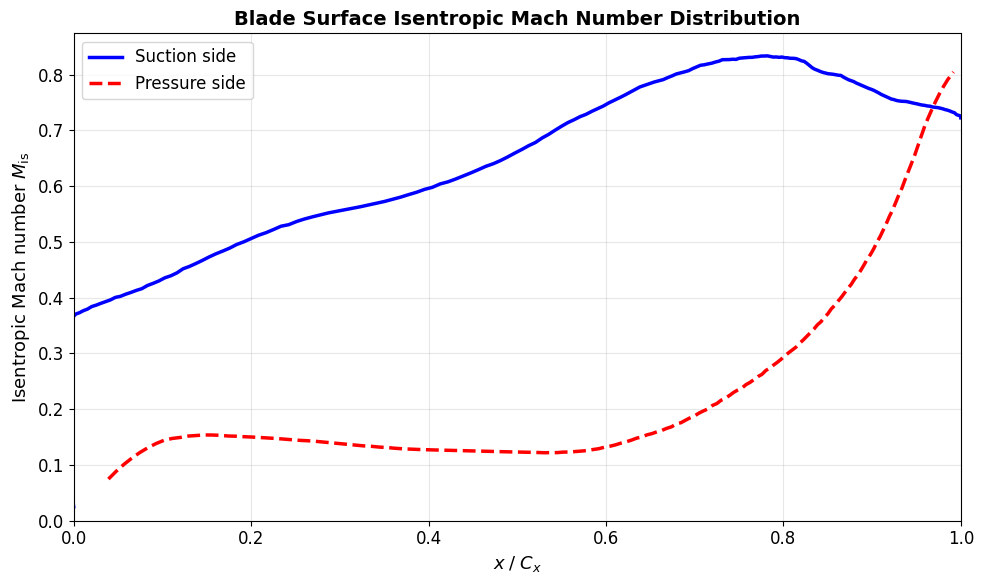

Points: 373 total | 213 suction | 160 pressure
M_is suction : 0.019 → 0.839
M_is pressure: 0.070 → 0.794


In [25]:
# ── Part 5c: Isentropic Mach number distribution ─────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.spatial import cKDTree

gam  = 1.33
P_t0 = 1521338.145   # inlet total pressure [Pa]

df = pd.read_csv('/Users/sanju/Projects/Python/Turbine Stage Design/surface_flow.csv',
                 skipinitialspace=True)
df.columns = df.columns.str.strip().str.replace('"', '')

x    = df['x'].values
y    = df['y'].values
rhoE = df['Energy'].values

# Wall pressure (V=0 at no-slip wall → P = (γ-1)·ρE)
P     = (gam - 1.0) * rhoE
M_is  = np.sqrt((2.0 / (gam - 1.0)) * ((P_t0 / P) ** ((gam - 1.0) / gam) - 1.0))
x_norm = x / Cx

# ── KDTree side classification ────────────────────────────────────────────────
suc_tree = cKDTree(np.column_stack([xs_us, ys_us]))
pre_tree = cKDTree(np.column_stack([xs_ls, ys_ls]))

d_suc, idx_suc = suc_tree.query(np.column_stack([x, y]))
d_pre, idx_pre = pre_tree.query(np.column_stack([x, y]))

is_suc = d_suc <= d_pre
is_pre = ~is_suc

# ── KEY FIX: sort by arc-length from LE using parablade index ────────────────
# us_n: index 0 → TE,  index N_surf-1 → LE  ∴ arc from LE = (N_surf-1 - idx)
# ls_n: index 0 → LE,  index N_surf-1 → TE  ∴ arc from LE = idx

arc_suc = (N_surf - 1) - idx_suc[is_suc]
arc_pre =               idx_pre[is_pre]

suc_ord = np.argsort(arc_suc)
pre_ord = np.argsort(arc_pre)

x_suc = x_norm[is_suc][suc_ord]
M_suc = M_is  [is_suc][suc_ord]
x_pre = x_norm[is_pre][pre_ord]
M_pre = M_is  [is_pre][pre_ord]

# ── Filter out any invalid points (P≤0 → inf in M_is) ───────────────────────
valid_suc = np.isfinite(M_suc) & (M_suc > 0)
valid_pre = np.isfinite(M_pre) & (M_pre > 0)

x_suc = x_suc[valid_suc];  M_suc = M_suc[valid_suc]
x_pre = x_pre[valid_pre];  M_pre = M_pre[valid_pre]

print(f"Valid points after filter: {valid_suc.sum()} suction | {valid_pre.sum()} pressure")

# ── Light smoothing ───────────────────────────────────────────────────────────
from scipy.signal import savgol_filter

def safe_savgol(arr, max_w=9, poly=2):
    """Savgol with automatic window clamped to array length."""
    n = len(arr)
    if n < 5:
        return arr                          # too short to smooth
    w = min(max_w, n)
    if w % 2 == 0:
        w -= 1                              # window must be odd
    if w <= poly:
        w = poly + 1 if (poly + 1) % 2 else poly + 2
    return savgol_filter(arr, window_length=w, polyorder=poly)

M_suc_sm = safe_savgol(M_suc)
M_pre_sm = safe_savgol(M_pre)

# ── Light smoothing (compensates for coarse mesh) ────────────────────────────
from scipy.signal import savgol_filter
w = min(9, len(M_suc) // 4 * 2 + 1)   # window must be odd
M_suc_sm = safe_savgol(M_suc, max_w=15, poly=2)
M_pre_sm = safe_savgol(M_pre, max_w=15, poly=2)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_suc, M_suc_sm, 'b-',  lw=2.5, label='Suction side')
ax.plot(x_pre, M_pre_sm, 'r--', lw=2.5, label='Pressure side')

ax.set_xlabel(r'$x \;/\; C_x$',                          fontsize=13)
ax.set_ylabel(r'Isentropic Mach number $M_\mathrm{is}$', fontsize=13)
ax.set_title('Blade Surface Isentropic Mach Number Distribution',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_xlim([0, 1])
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'Isentropic_Mach.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"Points: {len(x)} total | {is_suc.sum()} suction | {is_pre.sum()} pressure")
print(f"M_is suction : {M_suc.min():.3f} → {M_suc.max():.3f}")
print(f"M_is pressure: {M_pre.min():.3f} → {M_pre.max():.3f}")

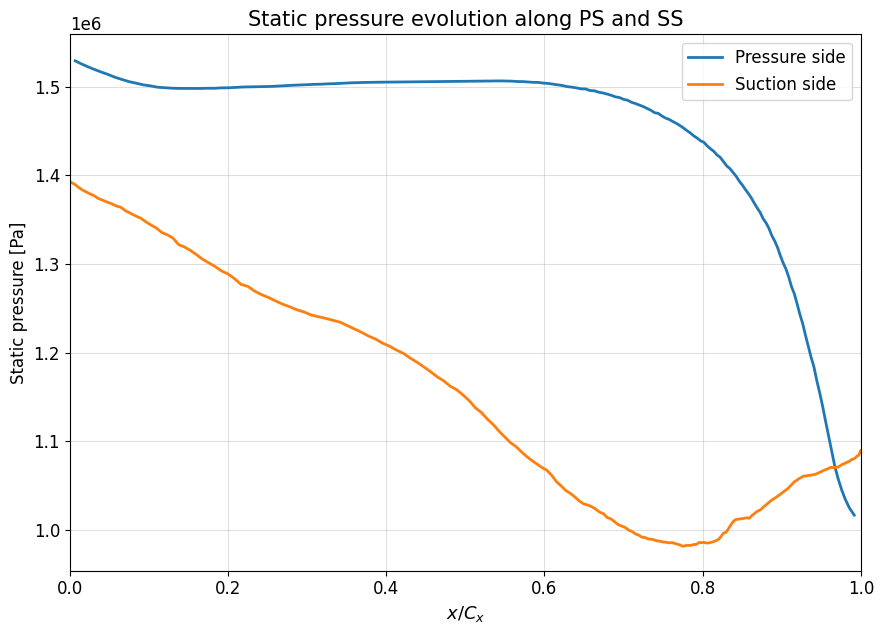

PS static pressure: 1.021 .. 1.527 MPa
SS static pressure: 0.977 .. 1.521 MPa


In [26]:
# ── Part 5g: Static pressure distribution along PS and SS ─────────────────────
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os
from scipy.spatial import cKDTree
from scipy.signal import savgol_filter

gam = 1.33
df = pd.read_csv('/Users/sanju/Projects/Python/Turbine Stage Design/surface_flow.csv',
                 skipinitialspace=True)
df.columns = df.columns.str.strip().str.replace('"', '')
x  = df['x'].values;  y = df['y'].values
rho = df['Density'].values
mx, my = df['Momentum_x'].values, df['Momentum_y'].values
E  = df['Energy'].values
# static pressure  p = (gamma-1) * (rho*E_tot - 0.5*|rho*V|^2 / rho)
P  = (gam - 1.0) * (E - 0.5 * (mx**2 + my**2) / rho)

# classify suction / pressure side and order LE -> TE
suc_tree = cKDTree(np.column_stack([xs_us, ys_us]))
pre_tree = cKDTree(np.column_stack([xs_ls, ys_ls]))
d_suc, idx_suc = suc_tree.query(np.column_stack([x, y]))
d_pre, idx_pre = pre_tree.query(np.column_stack([x, y]))
is_suc = d_suc <= d_pre
arc_suc = (N_surf - 1) - idx_suc[is_suc]      # us index 0->TE  => arc from LE
arc_pre =               idx_pre[~is_suc]      # ls index 0->LE  => arc from LE
x_suc = (x / Cx)[is_suc][np.argsort(arc_suc)];  P_suc = P[is_suc][np.argsort(arc_suc)]
x_pre = (x / Cx)[~is_suc][np.argsort(arc_pre)]; P_pre = P[~is_suc][np.argsort(arc_pre)]

def _smooth(a, w=11, p=2):
    n = len(a)
    if n < 5: return a
    w = min(w, n); w -= (w % 2 == 0)
    return savgol_filter(a, w, p) if w > p else a

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.plot(x_pre, _smooth(P_pre), color='C0', lw=2, label='Pressure side')
ax.plot(x_suc, _smooth(P_suc), color='C1', lw=2, label='Suction side')
ax.set_xlabel(r'$x/C_x$', fontsize=13)
ax.set_ylabel('Static pressure [Pa]', fontsize=12)
ax.set_title('Static pressure evolution along PS and SS', fontsize=15)
ax.legend(fontsize=12);  ax.grid(True, alpha=0.4);  ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'Pressure Distribution.png'), dpi=200, bbox_inches='tight')
plt.show()

print(f"PS static pressure: {P_pre.min()/1e6:.3f} .. {P_pre.max()/1e6:.3f} MPa")
print(f"SS static pressure: {P_suc.min()/1e6:.3f} .. {P_suc.max()/1e6:.3f} MPa")


Extraction x = 0.1941 m  |  non-empty bins = 60 / 60
Mean Pt/Pt0 = 0.9783
Mean Mach   = 0.6813
Mean angle  = -70.70 deg


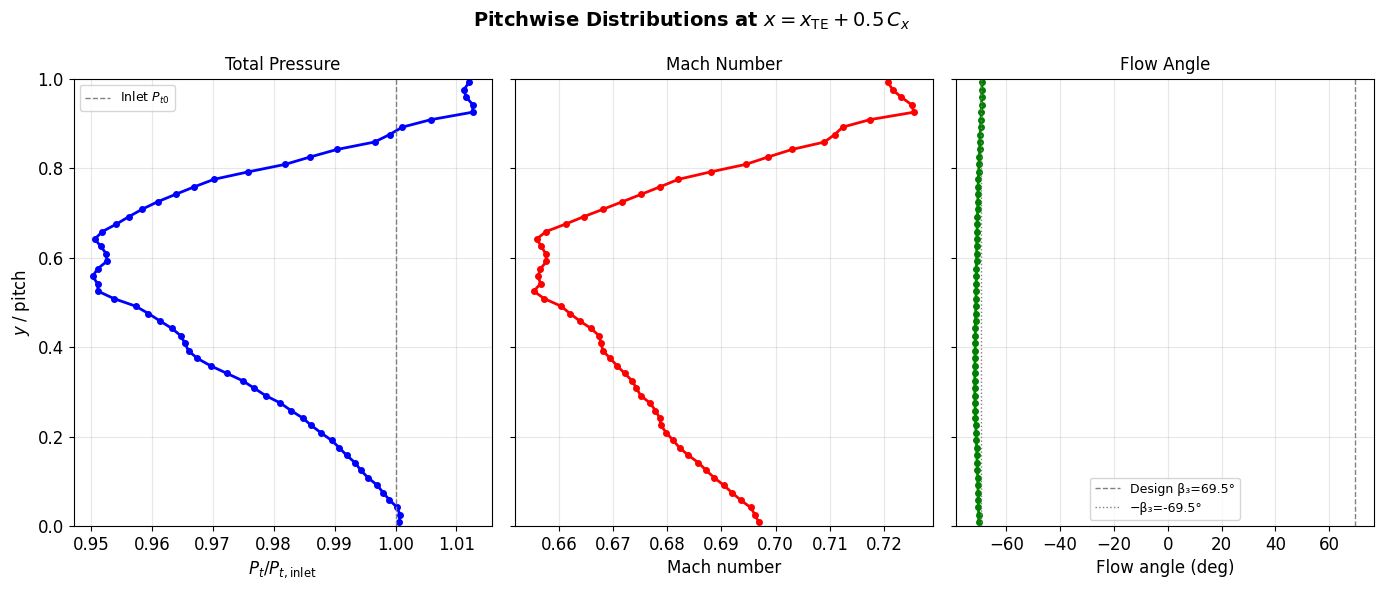

In [27]:
# ============================================================
# PART 5d -- Pitchwise distributions  (bin-averaged)
# ============================================================
import os, pyvista as pv, numpy as np, matplotlib.pyplot as plt

RESULTS = RESULTS if 'RESULTS' in dir() else '/Users/sanju/Projects/Python/Turbine Stage Design'
mesh = pv.read('/Users/sanju/Projects/Python/Turbine Stage Design/flow.vtu')

gam = 1.33;  R = 287.0;  cp = gam * R / (gam - 1)
P_v   = mesh['Pressure'];      T_v   = mesh['Temperature']
vel_v = mesh['Velocity'];      Vx    = vel_v[:,0];  Vy = vel_v[:,1]
V2    = Vx**2 + Vy**2

T_t   = T_v + V2 / (2*cp)
P_t   = P_v * (T_t / T_v) ** (gam / (gam-1))
Mach  = np.sqrt(V2) / np.sqrt(gam * R * T_v)
alpha = np.rad2deg(np.arctan2(Vy, Vx))

mesh['TotalPressure'] = P_t
mesh['Mach_derived'] = mesh['Mach'] 
mesh['FlowAngle']     = alpha

# ── Line probe ────────────────────────────────────────────────────────────────
x_extract = TE_x + 0.30 * Cx          # inside the domain (off the outlet)
y_mid   = camber_y(x_extract)
y_bot_d = y_mid - pitch / 2
y_top_d = y_mid + pitch / 2
line = pv.Line(pointa=[x_extract, y_bot_d, 0],
               pointb=[x_extract, y_top_d, 0], resolution=500)
result = line.sample(mesh)   # line probe (sample field onto line points)

# Sort by y
y_probe  = result.points[:, 1]
s        = np.argsort(y_probe)
y_n      = (y_probe[s] - y_bot_d) / domain_height
Pt_raw   = result['TotalPressure'][s] / 1521338.145
M_raw    = result['Mach_derived'][s]
al_raw   = result['FlowAngle'][s]

# ── Bin-average (suppresses cell-crossing noise) ──────────────────────────────
N_BINS  = 60
edges   = np.linspace(0, 1, N_BINS + 1)
yc      = 0.5 * (edges[:-1] + edges[1:])

def bin_avg(vals, y, edges):
    out = np.full(len(edges)-1, np.nan)
    for i in range(len(out)):
        m = (y >= edges[i]) & (y < edges[i+1])
        if m.sum() > 0:
            out[i] = vals[m].mean()
    return out

Pt_b  = bin_avg(Pt_raw,  y_n, edges)
M_b   = bin_avg(M_raw,   y_n, edges)
al_b  = bin_avg(al_raw,  y_n, edges)

# Drop empty bins
ok = np.isfinite(Pt_b)
print(f'Extraction x = {x_extract:.4f} m  |  non-empty bins = {ok.sum()} / {N_BINS}')
print(f'Mean Pt/Pt0 = {np.nanmean(Pt_b):.4f}')
print(f'Mean Mach   = {np.nanmean(M_b):.4f}')
print(f'Mean angle  = {np.nanmean(al_b):.2f} deg')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharey=True)
fig.suptitle(r'Pitchwise Distributions at $x = x_\mathrm{TE} + 0.5\,C_x$',
             fontsize=14, fontweight='bold')

axes[0].plot(Pt_b[ok], yc[ok], 'b-o', lw=2, ms=4)
axes[0].axvline(1.0, color='grey', ls='--', lw=1, label='Inlet $P_{t0}$')
axes[0].set_xlabel(r'$P_t / P_{t,\mathrm{inlet}}$', fontsize=12)
axes[0].set_ylabel(r'$y \;/\; \mathrm{pitch}$',      fontsize=12)
axes[0].set_title('Total Pressure', fontsize=12)
axes[0].grid(True, alpha=0.3);  axes[0].legend(fontsize=9)
axes[0].set_ylim([0, 1])

axes[1].plot(M_b[ok], yc[ok], 'r-o', lw=2, ms=4)
axes[1].set_xlabel('Mach number', fontsize=12)
axes[1].set_title('Mach Number',  fontsize=12)
axes[1].grid(True, alpha=0.3)

axes[2].plot(al_b[ok], yc[ok], 'g-o', lw=2, ms=4)
axes[2].axvline( beta3, color='grey', ls='--', lw=1, label=f'Design β₃={beta3:.1f}°')
axes[2].axvline(-beta3, color='grey', ls=':',  lw=1, label=f'−β₃={-beta3:.1f}°')
axes[2].set_xlabel('Flow angle (deg)', fontsize=12)
axes[2].set_title('Flow Angle',        fontsize=12)
axes[2].grid(True, alpha=0.3);  axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'Pitchwise_Distributions.png'), dpi=300, bbox_inches='tight')
plt.show()

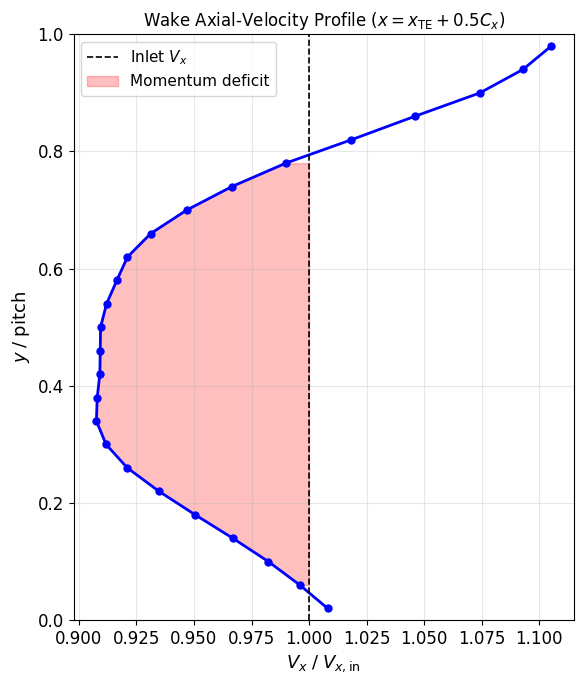

Vx_in = 174.5 m/s
Min Vx/Vx_in = 0.908  (wake deficit = 9.2%)


In [28]:
# ============================================================
# PART 5e – Wake axial-velocity profile (momentum deficit)
# ============================================================
import os, pyvista as pv, numpy as np, matplotlib.pyplot as plt

RESULTS = RESULTS if 'RESULTS' in dir() else '/Users/sanju/Projects/Python/Turbine Stage Design'
mesh = pv.read('/Users/sanju/Projects/Python/Turbine Stage Design/flow.vtu')

# Line probe at same x location
x_extract = TE_x + 0.30 * Cx          # inside the domain (off the outlet)
y_mid   = camber_y(x_extract)
y_bot_d = y_mid - pitch / 2
y_top_d = y_mid + pitch / 2
line = pv.Line(pointa=[x_extract, y_bot_d, 0],
               pointb=[x_extract, y_top_d, 0], resolution=500)
result = line.sample(mesh)   # line probe (sample field onto line points)

# Sort by y
y_probe  = result.points[:, 1]
s        = np.argsort(y_probe)
y_n      = (y_probe[s] - y_bot_d) / domain_height
Vx_probe = result['Velocity'][s, 0]

# Bin average
N_BINS = 25
edges  = np.linspace(0, 1, N_BINS + 1)
yc     = 0.5 * (edges[:-1] + edges[1:])

def bin_avg(vals, y, edges):
    out = np.full(len(edges)-1, np.nan)
    for i in range(len(out)):
        m = (y >= edges[i]) & (y < edges[i+1])
        if m.sum() > 0:
            out[i] = vals[m].mean()
    return out

from scipy.signal import savgol_filter

def smooth_valid(arr, w=5, p=2):
    ok = np.isfinite(arr)
    if ok.sum() < w:
        return arr
    out = arr.copy()
    out[ok] = savgol_filter(arr[ok], window_length=min(w, ok.sum()//2*2+1), polyorder=p)
    return out

Pt_b  = smooth_valid(bin_avg(Pt_raw,  y_n, edges))   # Part 5d
M_b   = smooth_valid(bin_avg(M_raw,   y_n, edges))
al_b  = smooth_valid(bin_avg(al_raw,  y_n, edges))

Vx_b  = smooth_valid(bin_avg(Vx_probe, y_n, edges))  # Part 5e
ok   = np.isfinite(Vx_b)

# Inlet axial velocity
gam = 1.33; R = 287.0
T_in = 1578.0609 / (1 + (gam-1)/2 * 0.3081**2)
Vx_in = 0.3081 * np.sqrt(gam*R*T_in) * 0.7356093167

Vx_norm = Vx_b / Vx_in

fig, ax = plt.subplots(figsize=(6, 7))
ax.plot(Vx_norm[ok], yc[ok], 'b-o', lw=2, ms=5)
ax.axvline(1.0, color='k', ls='--', lw=1.2, label='Inlet $V_x$')
ax.fill_betweenx(yc[ok], Vx_norm[ok], 1.0,
                 where=(Vx_norm[ok] < 1.0),
                 alpha=0.25, color='red', label='Momentum deficit')
ax.set_xlabel(r'$V_x \;/\; V_{x,\mathrm{in}}$', fontsize=13)
ax.set_ylabel(r'$y \;/\; \mathrm{pitch}$',        fontsize=13)
ax.set_title(r'Wake Axial-Velocity Profile ($x = x_\mathrm{TE}+0.5C_x$)', fontsize=12)
ax.legend(fontsize=11);  ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'Wake_Velocity_Profile.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"Vx_in = {Vx_in:.1f} m/s")
print(f"Min Vx/Vx_in = {np.nanmin(Vx_norm):.3f}  (wake deficit = {100*(1-np.nanmin(Vx_norm)):.1f}%)")

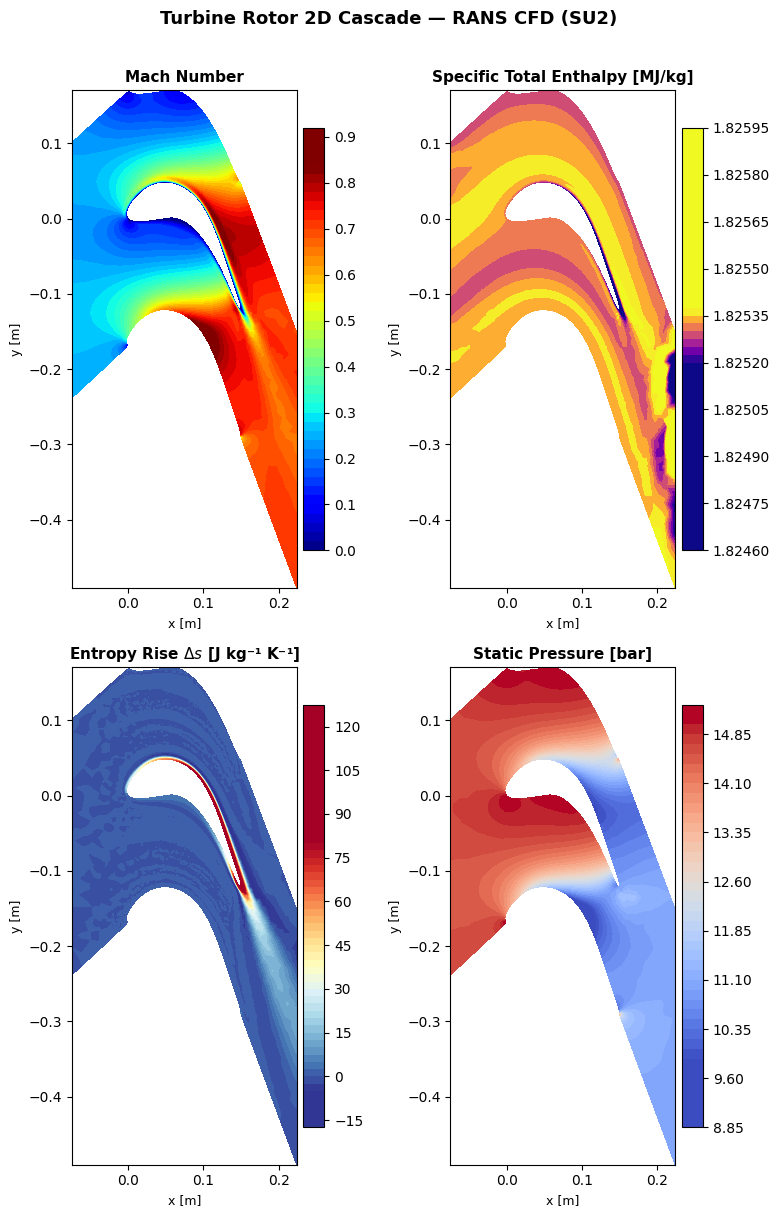

Colormaps saved.


In [9]:
# ============================================================
# PART 5f – CFD Flow Field Colormaps
# ============================================================
import pyvista as pv, numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri, os

RESULTS = RESULTS if 'RESULTS' in dir() else '/Users/sanju/Projects/Python/Turbine Stage Design/Report/Figures'
mesh     = pv.read('/Users/sanju/Projects/Python/Turbine Stage Design/flow.vtu')
mesh_tri = mesh.triangulate()
cells    = mesh_tri.cells.reshape(-1, 4)
tris     = cells[:, 1:]
xm = mesh_tri.points[:, 0];  ym = mesh_tri.points[:, 1]
triang   = mtri.Triangulation(xm, ym, tris)

gam = 1.33;  R = 287.0;  cp = gam*R/(gam-1)
T_t0 = 1578.0609;  P_t0 = 1521338.145

rho  = mesh_tri['Density']
P_v  = mesh_tri['Pressure']
T_v  = mesh_tri['Temperature']
rhoE = mesh_tri['Energy']
Mach = mesh_tri['Mach']

h_t  = (rhoE + P_v) / rho
ds   = cp*np.log(T_v/T_t0) - R*np.log(P_v/P_t0)

fig, axes = plt.subplots(2, 2, figsize=(8, 12))
panels = [
    (Mach,       'Mach Number',                               'jet'),
    (h_t/1e6,    'Specific Total Enthalpy [MJ/kg]',           'plasma'),
    (ds,          r'Entropy Rise $\Delta s$ [J kg⁻¹ K⁻¹]',  'RdYlBu_r'),
    (P_v/1e5,    'Static Pressure [bar]',                     'coolwarm'),
]
for ax, (field, title, cmap) in zip(axes.flat, panels):
    lo, hi = np.percentile(field, [2, 98])
    tcf = ax.tricontourf(triang, field, levels=60, cmap=cmap, vmin=lo, vmax=hi)
    plt.colorbar(tcf, ax=ax, shrink=0.85, pad=0.02)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('x [m]', fontsize=9);  ax.set_ylabel('y [m]', fontsize=9)
    ax.set_aspect('equal')

plt.suptitle('Turbine Rotor 2D Cascade — RANS CFD (SU2)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'CFD_Colormaps.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Colormaps saved.")